<a href="https://colab.research.google.com/github/ChristineHJLee5919/Data-Analysis-with-Open-Source/blob/main/Energy_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from matplotlib.gridspec import GridSpec

# ──────────────────────────────────────────────
# 0. 경로 설정
# ──────────────────────────────────────────────
PATH_DAILY  = "/content/서울에너지 시뮬레이션 일일단위자원별계측실적.csv"
PATH_HOURLY = "/content/서울에너지 시뮬레이션 시간단위자원별계측실적.csv"

# ──────────────────────────────────────────────
# 1. 데이터 로드
# ──────────────────────────────────────────────
print("=" * 60)
print("[1] 데이터 로드")
print("=" * 60)

daily_df  = pd.read_csv(PATH_DAILY)
hourly_df = pd.read_csv(PATH_HOURLY, engine='python', on_bad_lines='skip')

print(f"  일일 단위 원본 shape : {daily_df.shape}")
print(f"  시간 단위 원본 shape : {hourly_df.shape}")

# ──────────────────────────────────────────────
# 2. 날짜 컬럼 생성
# ──────────────────────────────────────────────
print("\n" + "=" * 60)
print("[2] 날짜 컬럼 생성")
print("=" * 60)


def create_date_column(df):
    df = df.copy()

    df["DATE"] = pd.to_datetime(
        df[["YYYY", "MM", "DD"]].rename(
            columns={
                "YYYY": "year",
                "MM": "month",
                "DD": "day"
            }
        )
    )

    return df


hourly_df = create_date_column(hourly_df)
daily_df = create_date_column(daily_df)

# 시간 단위 데이터는 HH를 이용해 DATETIME 컬럼 생성
# HH가 1~24이므로 HH=1을 00시, HH=24를 23시로 처리
hourly_df["DATETIME"] = hourly_df["DATE"] + pd.to_timedelta(hourly_df["HH"] - 1, unit="h")

print(hourly_df[["YYYY", "MM", "DD", "HH", "DATE", "DATETIME"]].head())
print(daily_df[["YYYY", "MM", "DD", "DATE"]].head())

# ──────────────────────────────────────────────
# 3. 결측치 확인
# ──────────────────────────────────────────────
print("\n" + "=" * 60)
print("[3] 결측치 확인 (원본 기준)")
print("=" * 60)

def missing_check(df, name):
    missing = pd.DataFrame({
        "missing_count": df.isnull().sum(),
        "missing_ratio": df.isnull().mean() * 100
    }).sort_values("missing_count", ascending=False)

    print(f"\n[{name}] 결측치 확인")
    print(missing)

    return missing


hourly_missing = missing_check(hourly_df, "시간 단위 데이터")
daily_missing = missing_check(daily_df, "일 단위 데이터")


# ──────────────────────────────────────────────
# 4. SOC_RATE 처리 (100% 결측 → 분리 보관)
# ──────────────────────────────────────────────
print("\n" + "=" * 60)
print("[4] SOC_RATE 처리")
print("=" * 60)

# SOC_RATE 결측률 확인
print("\n시간 단위 SOC_RATE 결측률:")
print(hourly_df["SOC_RATE"].isnull().mean() * 100)

print("\n일 단위 SOC_RATE 결측률:")
print(daily_df["SOC_RATE"].isnull().mean() * 100)

# 분석용 데이터에서 제외
exclude_cols = ["SOC_RATE", "USKI_AMOUNT"]
hourly_clean = hourly_df.drop(columns=exclude_cols)
daily_clean = daily_df.drop(columns=exclude_cols)

print("\n시간 단위 분석용 컬럼:")
print(hourly_clean.columns.tolist())

print("\n일 단위 분석용 컬럼:")
print(daily_clean.columns.tolist())

# ──────────────────────────────────────────────
# 5. 시간 단위 데이터를 일 단위로 집계
# ──────────────────────────────────────────────
print("\n" + "=" * 60)
print("[5] 시간 단위 데이터를 일 단위로 집계")
print("=" * 60)

# 시간 단위 데이터를 DATE, VPP_ID, RE_NUM 기준으로 일 단위 집계
# GEN_AMOUNT는 발전량이므로 합계
# USE_RATE는 사용률이므로 평균과 합계를 둘 다 생성

hourly_to_daily = (
    hourly_clean
    .groupby(["DATE", "VPP_ID", "RE_NUM"], as_index=False)
    .agg(
        GEN_AMOUNT_hourly_sum=("GEN_AMOUNT", "sum"),
        USE_RATE_hourly_mean=("USE_RATE", "mean"),
        USE_RATE_hourly_sum=("USE_RATE", "sum"),
        HOURLY_USE_MAX    = ("USE_RATE",   "max"),
        hourly_count=("HH", "count")
    )
)

print("\n시간 데이터를 일 단위로 집계한 결과:")
print(hourly_to_daily.head())
print(hourly_to_daily.shape)



# ──────────────────────────────────────────────
# 6. 일 단위 데이터와 시간 집계 데이터 병합
# ──────────────────────────────────────────────
print("\n" + "=" * 60)
print("[6] 일 단위 데이터와 시간 집계 데이터 병합")
print("=" * 60)

daily_clean = daily_clean.rename(columns={
    "GEN_AMOUNT": "GEN_AMOUNT_daily",
    "USE_RATE": "USE_RATE_daily"
})

merged_daily = pd.merge(
    daily_clean,
    hourly_to_daily,
    on=["DATE", "VPP_ID", "RE_NUM"],
    how="left"
)

print("\n병합 데이터 크기:")
print(merged_daily.shape)

print("\n병합 데이터 샘플:")
print(merged_daily.head())


# ──────────────────────────────────────────────
# 7. 병합 후 결측치 확인
# ──────────────────────────────────────────────
print("\n" + "=" * 60)
print("[7] 병합 후 결측치 확인")
print("=" * 60)

merged_missing = missing_check(merged_daily, "병합 후 데이터")

# 참고:
# 일 단위 데이터는 2021-12부터 있고,
# 시간 단위 데이터는 2022-07부터 있어서
# 초반 날짜는 시간 집계값이 NaN일 수 있음.


# ──────────────────────────────────────────────
# 8. 공통 기간만 사용하고 싶은 경우
# ──────────────────────────────────────────────
print("\n" + "=" * 60)
print("[8] 공통 기간만 사용하고 싶은 경우")
print("=" * 60)

merged_common = pd.merge(
    daily_clean,
    hourly_to_daily,
    on=["DATE", "VPP_ID", "RE_NUM"],
    how="inner"
)

print("\n공통 기간 기준 병합 데이터 크기:")
print(merged_common.shape)

print("\n공통 기간 기준 병합 데이터 샘플:")
print(merged_common.head())



# ──────────────────────────────────────────────
# 9. 최종 저장
# ──────────────────────────────────────────────
print("\n" + "=" * 60)
print("[9] 최종 저장")
print("=" * 60)

merged_daily.to_csv("preprocessed_daily_left_merge.csv", index=False, encoding="utf-8-sig")
merged_common.to_csv("preprocessed_daily_common_period.csv", index=False, encoding="utf-8-sig")
hourly_clean.to_csv("preprocessed_hourly_clean.csv", index=False, encoding="utf-8-sig")

print("\n저장 완료")
print("1) preprocessed_daily_left_merge.csv")
print("2) preprocessed_daily_common_period.csv")
print("3) preprocessed_hourly_clean.csv")

[1] 데이터 로드
  일일 단위 원본 shape : (327328, 9)
  시간 단위 원본 shape : (2790111, 10)

[2] 날짜 컬럼 생성
   YYYY  MM  DD  HH       DATE            DATETIME
0  2022   7  13  13 2022-07-13 2022-07-13 12:00:00
1  2022   7  13  13 2022-07-13 2022-07-13 12:00:00
2  2022   7  13  13 2022-07-13 2022-07-13 12:00:00
3  2022   7  13  13 2022-07-13 2022-07-13 12:00:00
4  2022   7  13  13 2022-07-13 2022-07-13 12:00:00
   YYYY  MM  DD       DATE
0  2021  12   1 2021-12-01
1  2021  12   1 2021-12-01
2  2021  12   1 2021-12-01
3  2021  12   1 2021-12-01
4  2021  12   1 2021-12-01

[3] 결측치 확인 (원본 기준)

[시간 단위 데이터] 결측치 확인
             missing_count  missing_ratio
SOC_RATE           2790111     100.000000
USKI_AMOUNT              1       0.000036
GEN_AMOUNT               1       0.000036
USE_RATE                 1       0.000036
VPP_ID                   1       0.000036
MM                       0       0.000000
YYYY                     0       0.000000
RE_NUM                   0       0.000000
DD                       


[10] 분석용 기본 요약
전체 일 단위 데이터 기간
2021-12-01 00:00:00 ~ 2025-11-24 00:00:00

공통 기간 데이터 기간
2022-07-13 00:00:00 ~ 2024-02-22 00:00:00

시간 단위 데이터 기간
2022-07-13 12:00:00 ~ 2024-02-22 09:00:00

VPP 개수: 17
자원(RE_NUM) 개수: 97
[Analysis 1] Yearly Generation & Utilization Trend
 YYYY  Total_Gen     Avg_Gen   Avg_Use  Max_Use_Avg  Count
 2022   98106441 4107.621881 12.538673    51.446649  23884
 2023  495607288 6118.004246 14.213449    54.913230  81008
 2024   54285721 4660.118551 10.164007    44.851058  11649


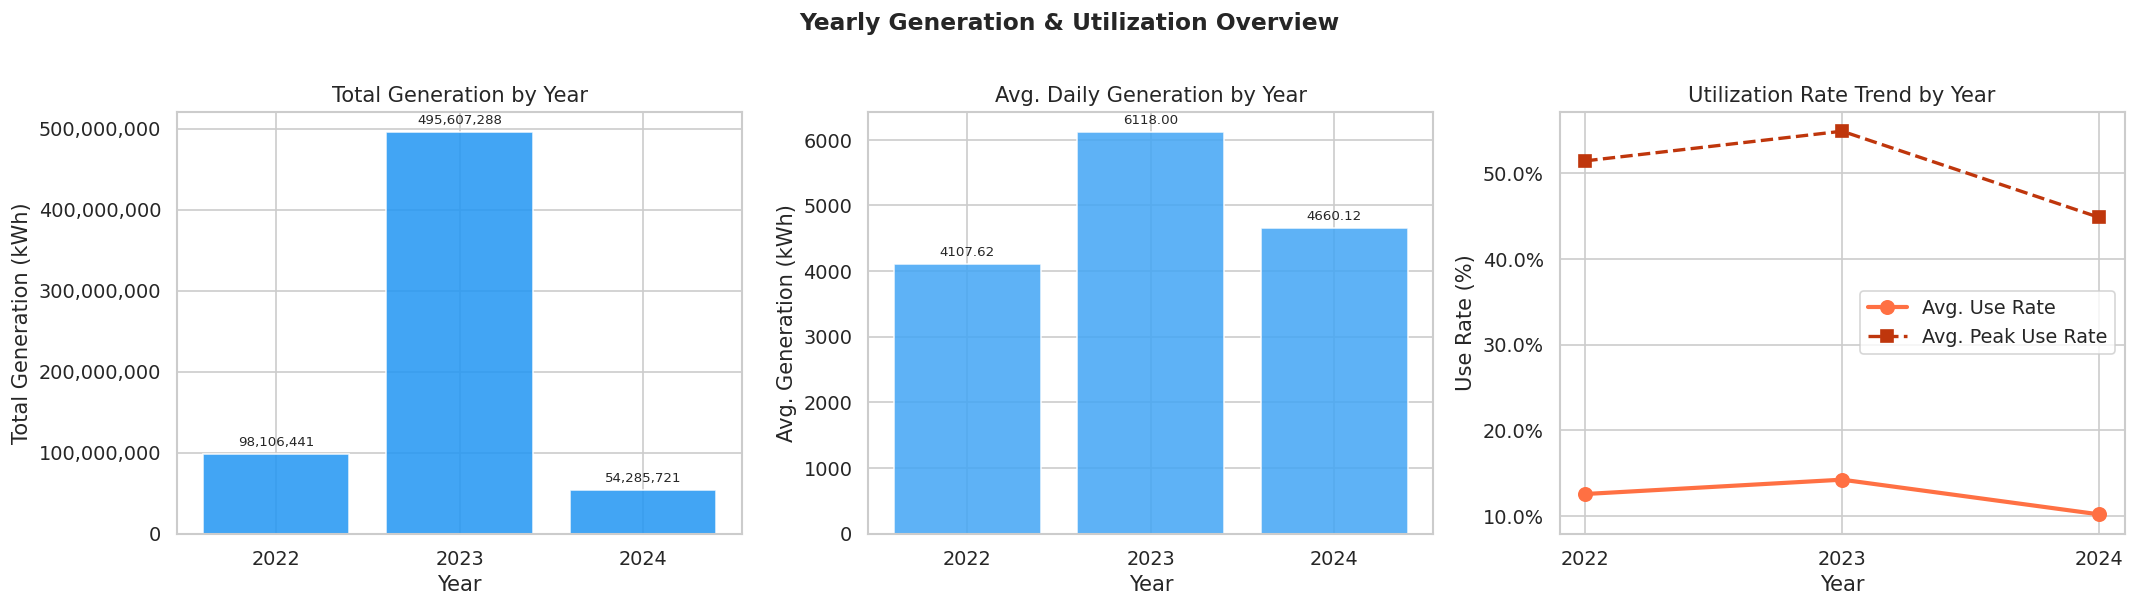


[Analysis 2] Monthly Generation & Utilization Trend
 MM  Total_Gen     Avg_Gen   Avg_Use Month
  1   50419450 3751.726319  8.750828   Jan
  2   63348935 5769.484062 12.718536   Feb
  3   53652431 7761.092290 17.968268   Mar
  4   60571692 9054.064574 20.959451   Apr
  5   51014786 7379.543758 17.130295   May
  6   47835579 7150.310762 16.632327   Jun
  7   41679997 4424.158476 10.942867   Jul
  8   60942552 5537.714857 14.134916   Aug
  9   57338061 5383.855493 13.797033   Sep
 10   65705997 5970.558564 15.291547   Oct
 11   51337166 4592.286072 11.702409   Nov
 12   44152804 3787.989362  9.712543   Dec


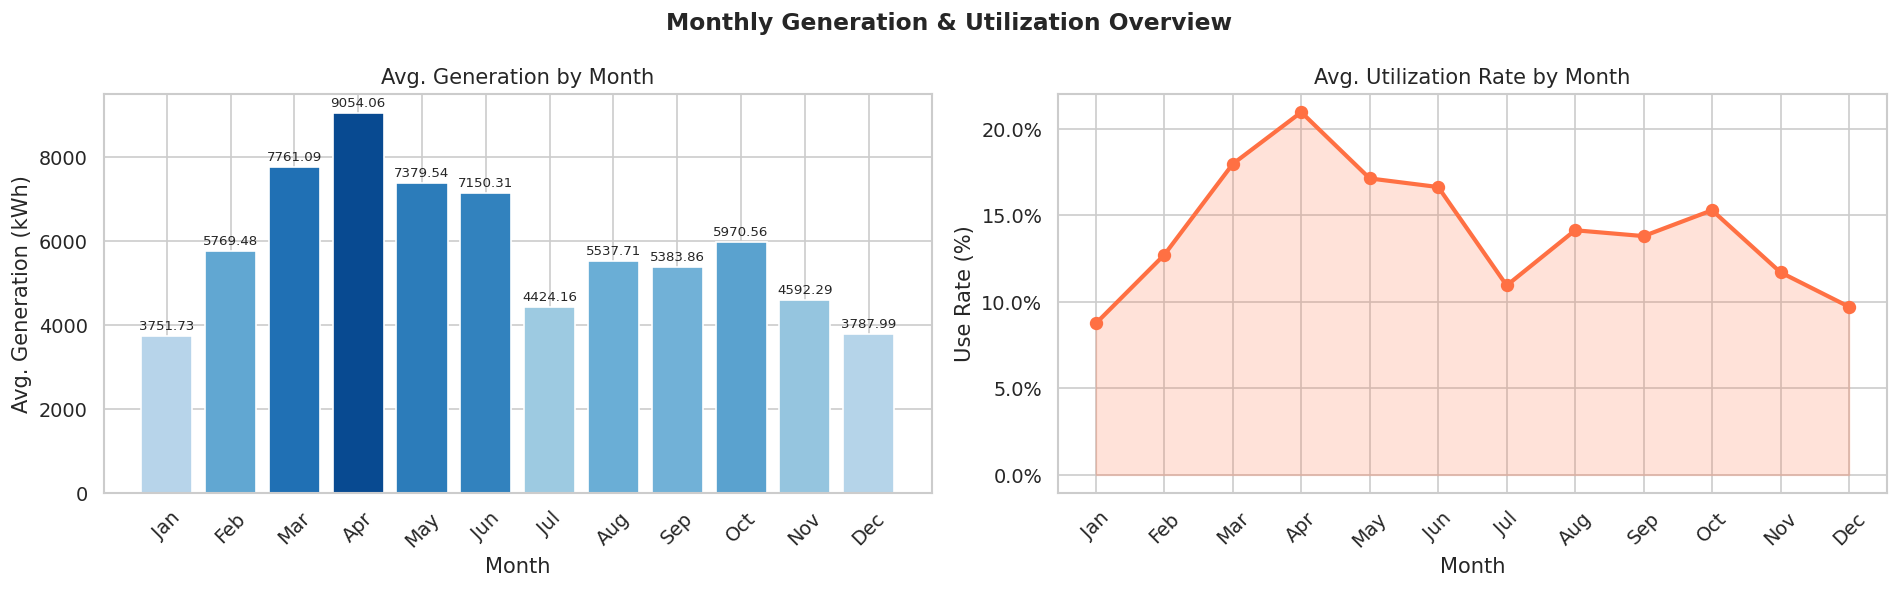

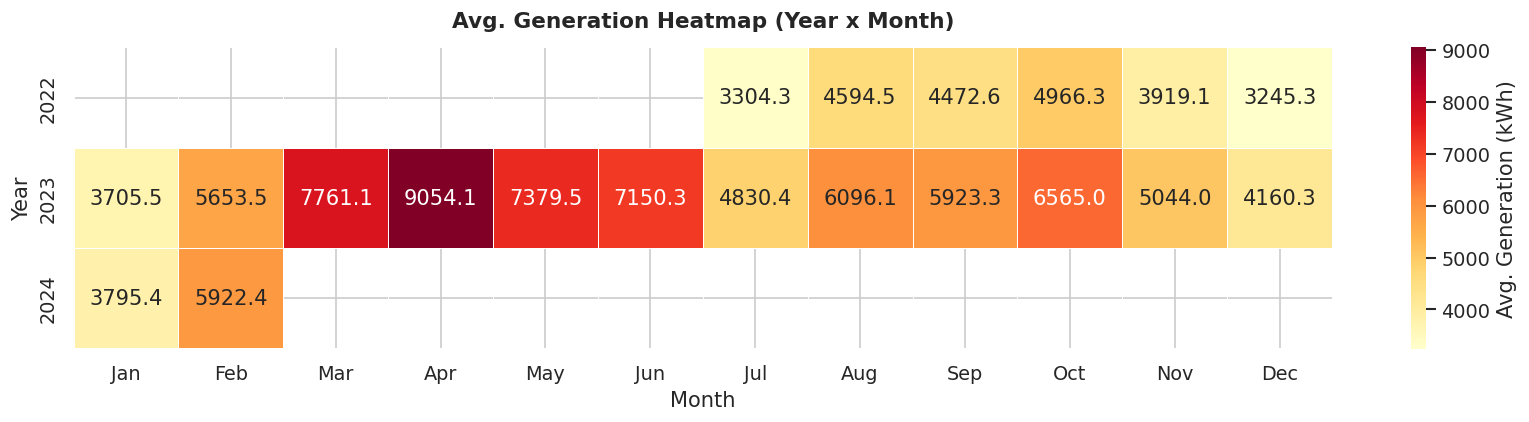


[Analysis 3] Hourly Generation & Utilization Pattern
 HH    Avg_Gen    Tot_Gen   Avg_Use
  1   0.000000        0.0  0.000000
  2   0.000000        0.0  0.000000
  3   0.000000        0.0  0.000000
  4   0.000000        0.0  0.000000
  5   0.000000        0.0  0.000000
  6   0.241561    28103.0  0.025578
  7   7.698674   895656.0  0.870881
  8  44.714653  5202058.0  5.179915
  9 130.275522 15156124.0 15.076994
 10 241.045941 28033884.0 27.764479
 11 334.799798 38851173.0 38.383010
 12 398.011668 46186468.0 45.512316
 13 421.664558 48986880.0 48.146773
 14 406.078898 47176216.0 46.251853
 15 354.935244 41234602.0 40.358444
 16 269.251598 31261726.0 30.483009
 17 154.606646 17996059.0 17.474099
 18  59.316031  6902132.0  6.652685
 19  13.020591  1515102.0  1.435321
 20   0.732817    85272.0  0.072944
 21   0.000000        0.0  0.000000
 22   0.000000        0.0  0.000000
 23   0.000000        0.0  0.000000
 24   0.000000        0.0  0.000000


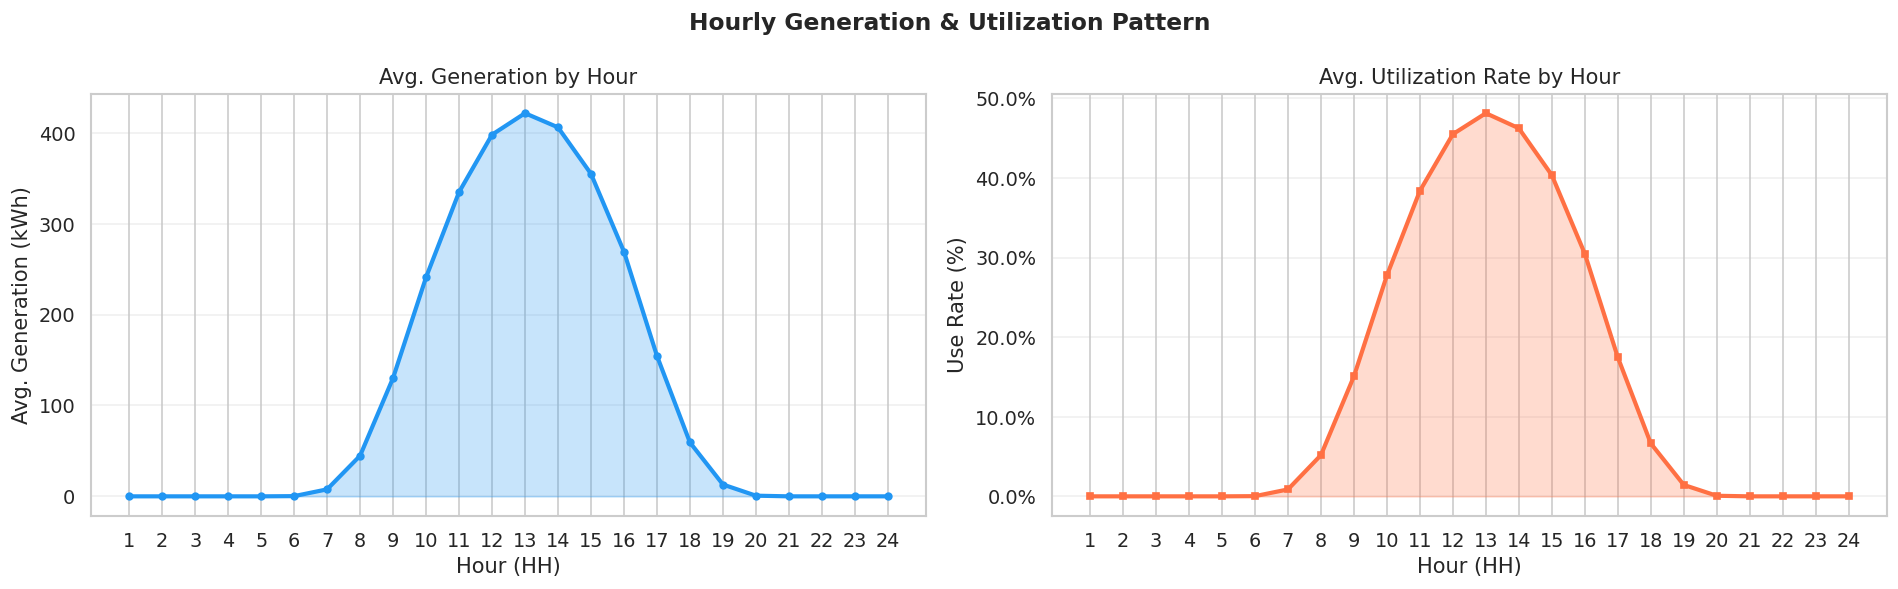

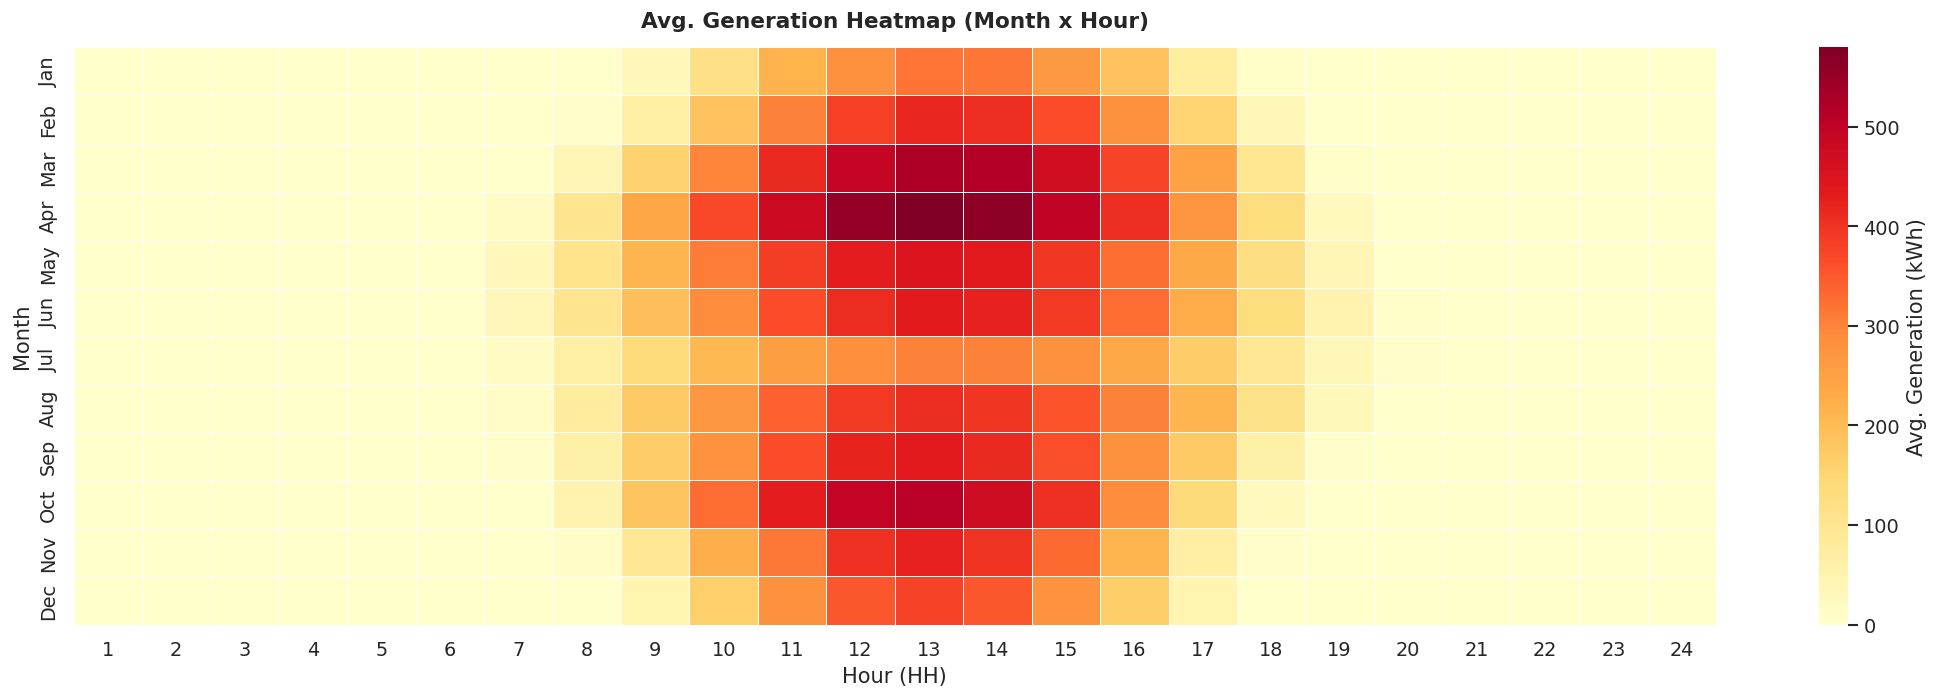


[Analysis 4] Top / Bottom Resources (RE_NUM)

>> Top 10 by Total Generation
 RE_NUM               VPP_ID  Total_Gen   Avg_Use
  56456 VPP20211209000000001   38621897 14.673066
   2504 VPP20211130000000002   13213438 14.004140
  14811 VPP20211130000000001   12998254 15.457564
  29343 VPP20211130000000002    9566540 13.585366
  61920 VPP20211130000000001    9498563 13.485349
  53323 VPP20211130000000002    6420103 15.207922
  56203 VPP20211130000000001    6039709 14.304923
   1819 VPP20211130000000002    5875073 14.209319
  29447 VPP20220426000000001    5842269 15.293867
  29447 VPP20211129000000001    5842269 15.293867

>> Bottom 10 by Total Generation
 RE_NUM               VPP_ID  Total_Gen  Avg_Use
  28313 VPP20240219000000001          0    0.000
  25903 VPP20240207000000001         76    0.158
  99912 VPP20240207000000001       2239    3.472
  42993 VPP20240219000000001       2703   18.885
  42993 VPP20240207000000001       2791   10.060
  32595 VPP20240207000000001       3246    8.

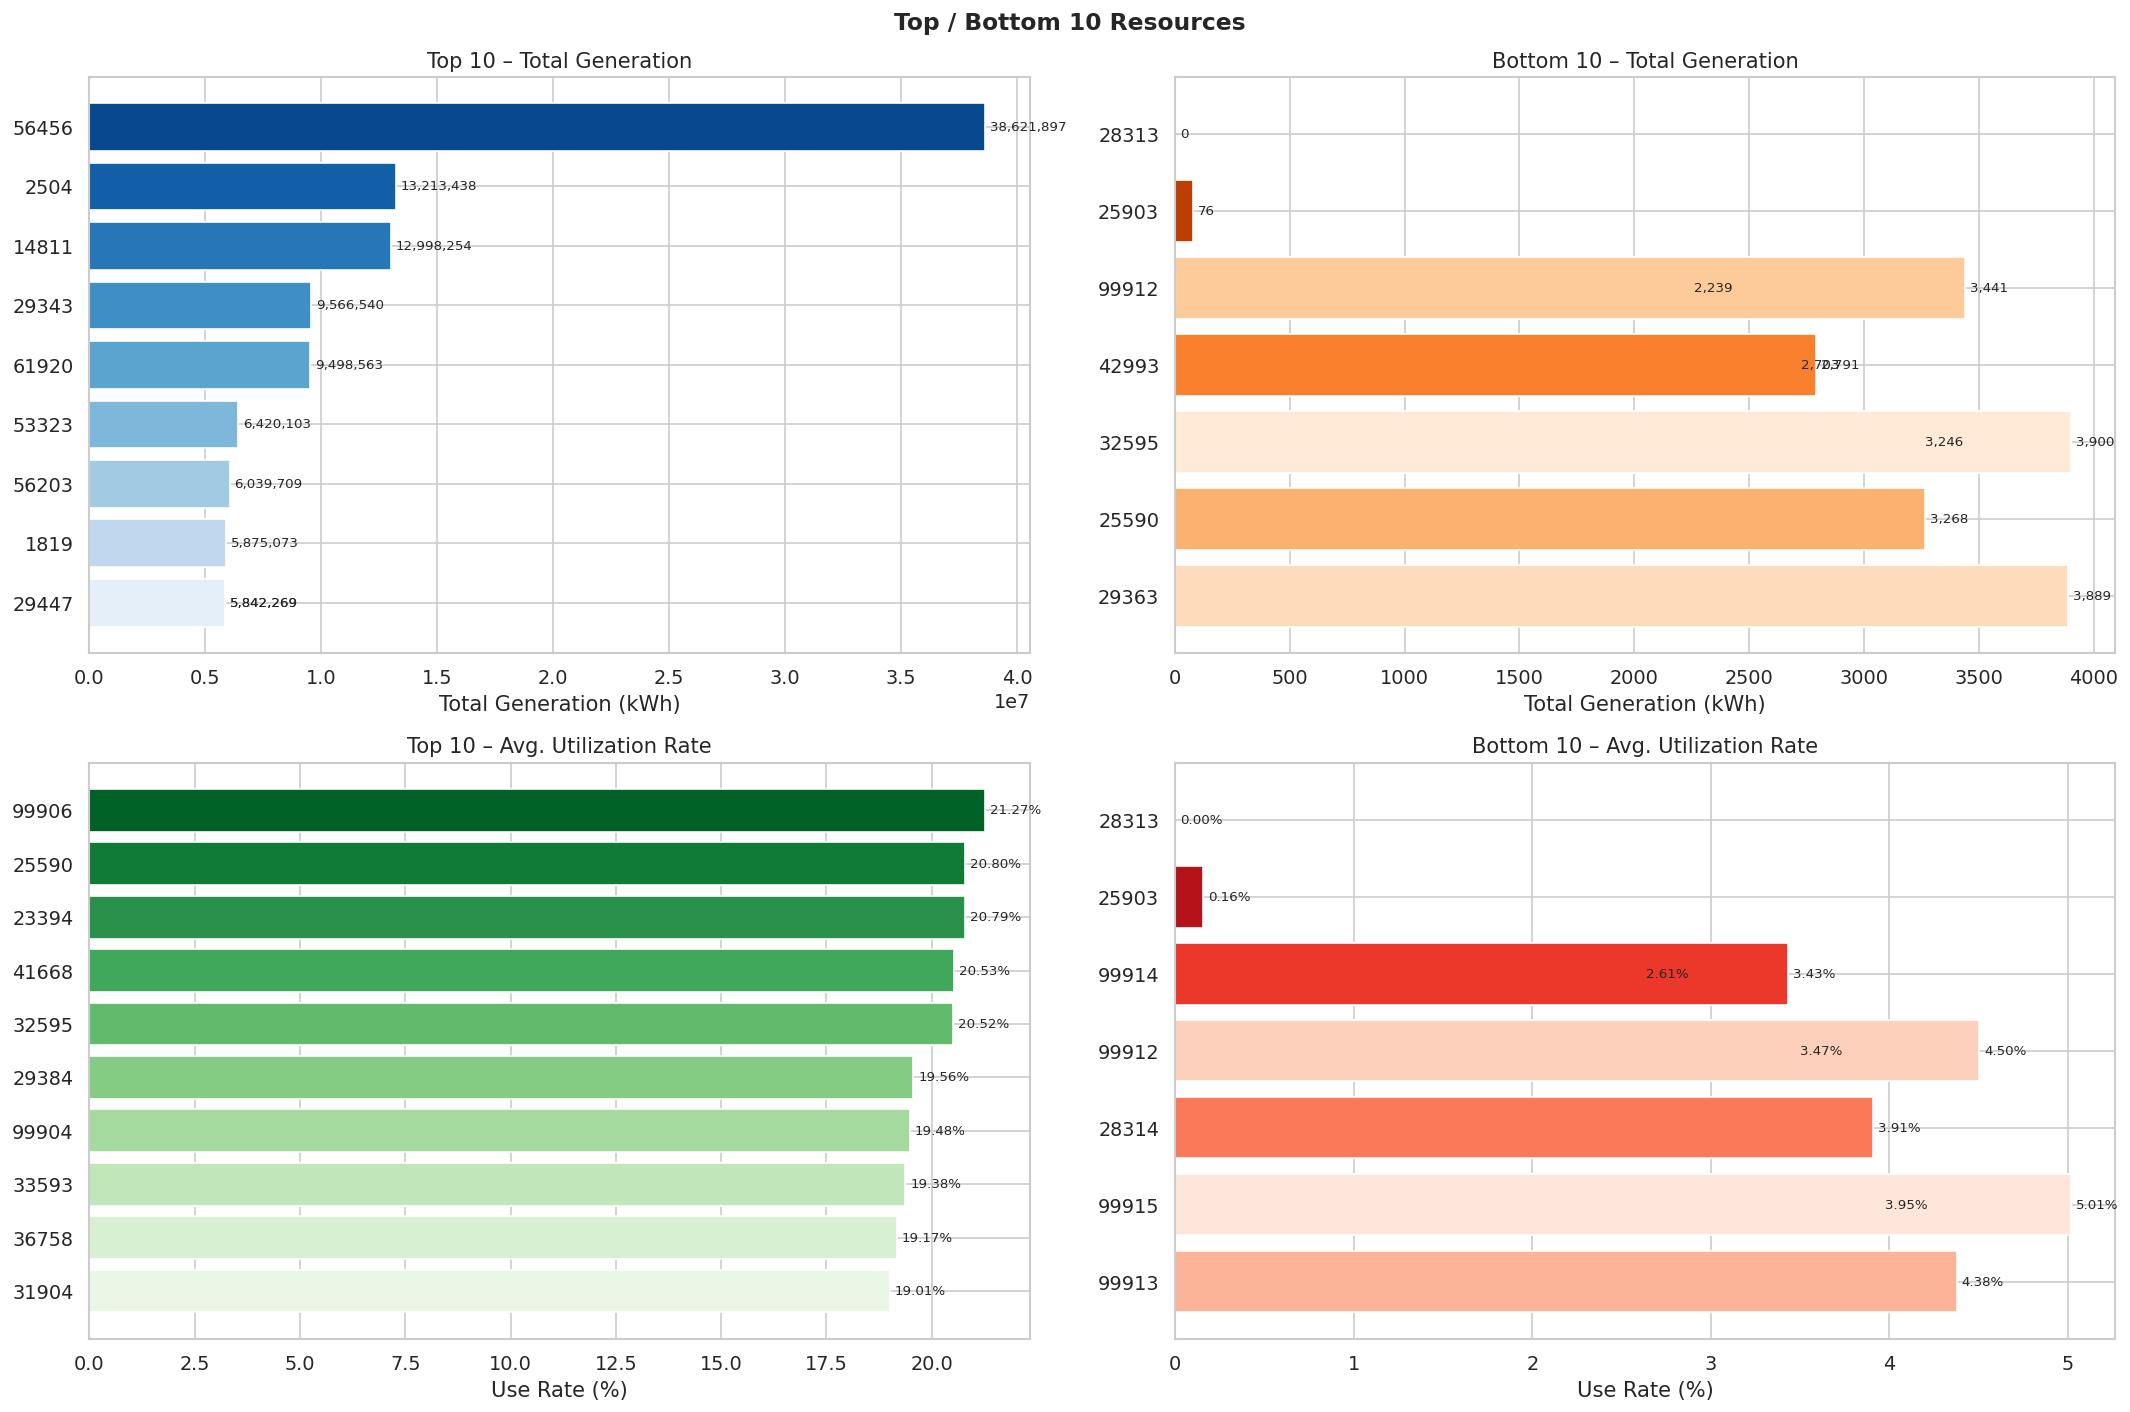

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Font / Style Settings ─────────────────────────────────
plt.rcParams['font.family']      = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi']       = 120
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.05)

# ── Common Palette ────────────────────────────────────────
COLOR_GEN    = "#2196F3"
COLOR_USE    = "#FF7043"
PALETTE_VPP  = "Set2"
FIGSIZE_WIDE = (16, 5)
TOP_N        = 10

MONTH_LABELS = {
    1:"Jan",2:"Feb",3:"Mar",4:"Apr",5:"May",6:"Jun",
    7:"Jul",8:"Aug",9:"Sep",10:"Oct",11:"Nov",12:"Dec"
}


# ──────────────────────────────────────────────
# 10. 분석용 기본 요약
# ──────────────────────────────────────────────
print("\n" + "=" * 60)
print("[10] 분석용 기본 요약")
print("=" * 60)

print("전체 일 단위 데이터 기간")
print(merged_daily["DATE"].min(), "~", merged_daily["DATE"].max())

print("\n공통 기간 데이터 기간")
print(merged_common["DATE"].min(), "~", merged_common["DATE"].max())

print("\n시간 단위 데이터 기간")
print(hourly_clean["DATETIME"].min(), "~", hourly_clean["DATETIME"].max())

print("\nVPP 개수:", merged_daily["VPP_ID"].nunique())
print("자원(RE_NUM) 개수:", merged_daily["RE_NUM"].nunique())


# ============================================================
# Analysis 1. Yearly Trend
# ============================================================
print("=" * 60)
print("[Analysis 1] Yearly Generation & Utilization Trend")
print("=" * 60)

yearly = (
    merged_common
    .groupby("YYYY")
    .agg(
        Total_Gen   = ("GEN_AMOUNT_daily",     "sum"),
        Avg_Gen     = ("GEN_AMOUNT_daily",     "mean"),
        Avg_Use     = ("USE_RATE_daily",       "mean"),
        Max_Use_Avg = ("HOURLY_USE_MAX", "mean"),
        Count       = ("GEN_AMOUNT_daily",     "count"),
    )
    .reset_index()
)
print(yearly.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Yearly Generation & Utilization Overview", fontsize=14, fontweight="bold", y=1.01)

# 1-1 Total Generation
ax = axes[0]
bars = ax.bar(yearly["YYYY"].astype(str), yearly["Total_Gen"],
              color=COLOR_GEN, alpha=0.85, edgecolor="white")
ax.bar_label(bars, fmt="{:,.0f}", fontsize=8, padding=3)
ax.set_title("Total Generation by Year")
ax.set_xlabel("Year")
ax.set_ylabel("Total Generation (kWh)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

# 1-2 Average Generation
ax = axes[1]
bars = ax.bar(yearly["YYYY"].astype(str), yearly["Avg_Gen"],
              color="#42A5F5", alpha=0.85, edgecolor="white")
ax.bar_label(bars, fmt="{:.2f}", fontsize=8, padding=3)
ax.set_title("Avg. Daily Generation by Year")
ax.set_xlabel("Year")
ax.set_ylabel("Avg. Generation (kWh)")

# 1-3 Utilization Rate
ax = axes[2]
ax.plot(yearly["YYYY"].astype(str), yearly["Avg_Use"],
        marker="o", color=COLOR_USE, linewidth=2.5, markersize=8, label="Avg. Use Rate")
ax.plot(yearly["YYYY"].astype(str), yearly["Max_Use_Avg"],
        marker="s", color="#BF360C", linewidth=2, linestyle="--",
        markersize=7, label="Avg. Peak Use Rate")
ax.set_title("Utilization Rate Trend by Year")
ax.set_xlabel("Year")
ax.set_ylabel("Use Rate (%)")
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}%"))

plt.tight_layout()
plt.savefig("01_yearly_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print()



# ============================================================
# Analysis 2. Monthly Trend
# ============================================================
print("=" * 60)
print("[Analysis 2] Monthly Generation & Utilization Trend")
print("=" * 60)

monthly = (
    merged_common
    .groupby("MM")
    .agg(
        Total_Gen = ("GEN_AMOUNT_daily", "sum"), # Changed to GEN_AMOUNT_daily
        Avg_Gen   = ("GEN_AMOUNT_daily", "mean"), # Changed to GEN_AMOUNT_daily
        Avg_Use   = ("USE_RATE_daily",   "mean"), # Changed to USE_RATE_daily
    )
    .reset_index()
)
monthly["Month"] = monthly["MM"].map(MONTH_LABELS)
print(monthly.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_WIDE)
fig.suptitle("Monthly Generation & Utilization Overview", fontsize=14, fontweight="bold")

# 2-1 Monthly Avg Generation (color-gradient bars)
ax = axes[0]
norm_vals = (monthly["Avg_Gen"] - monthly["Avg_Gen"].min()) / \
            (monthly["Avg_Gen"].max() - monthly["Avg_Gen"].min() + 1e-9)
colors = plt.cm.Blues(0.3 + 0.6 * norm_vals)
bars = ax.bar(monthly["Month"], monthly["Avg_Gen"], color=colors, edgecolor="white")
ax.bar_label(bars, fmt="{:.2f}", fontsize=8, padding=2)
ax.set_title("Avg. Generation by Month")
ax.set_xlabel("Month")
ax.set_ylabel("Avg. Generation (kWh)")
ax.tick_params(axis="x", rotation=45)

# 2-2 Monthly Avg Use Rate (area line)
ax = axes[1]
ax.fill_between(monthly["Month"], monthly["Avg_Use"],
                alpha=0.2, color=COLOR_USE)
ax.plot(monthly["Month"], monthly["Avg_Use"],
        marker="o", color=COLOR_USE, linewidth=2.5, markersize=7)
ax.set_title("Avg. Utilization Rate by Month")
ax.set_xlabel("Month")
ax.set_ylabel("Use Rate (%)")
ax.tick_params(axis="x", rotation=45)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}%"))

plt.tight_layout()
plt.savefig("02_monthly_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

# Year × Month Heatmap
pivot_gen = merged_common.pivot_table( # Changed merged_df to merged_common
    index="YYYY", columns="MM", values="GEN_AMOUNT_daily", aggfunc="mean" # Changed GEN_AMOUNT to GEN_AMOUNT_daily
)
pivot_gen.columns = [MONTH_LABELS[c] for c in pivot_gen.columns]

fig, ax = plt.subplots(figsize=(14, max(3, len(pivot_gen) * 0.9 + 1)))
sns.heatmap(pivot_gen, annot=True, fmt=".1f", cmap="YlOrRd",
            linewidths=0.5, linecolor="white", ax=ax,
            cbar_kws={"label": "Avg. Generation (kWh)"})
ax.set_title("Avg. Generation Heatmap (Year x Month)",
             fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Month")
ax.set_ylabel("Year")
plt.tight_layout()
plt.savefig("02_yearly_monthly_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print()



# ============================================================
# Analysis 3. Hourly Pattern
# ============================================================
print("=" * 60)
print("[Analysis 3] Hourly Generation & Utilization Pattern")
print("=" * 60)

hourly_pattern = (
    hourly_clean
    .groupby("HH")
    .agg(
        Avg_Gen = ("GEN_AMOUNT", "mean"),
        Tot_Gen = ("GEN_AMOUNT", "sum"),
        Avg_Use = ("USE_RATE",   "mean"),
    )
    .reset_index()
)
print(hourly_pattern.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE_WIDE)
fig.suptitle("Hourly Generation & Utilization Pattern", fontsize=14, fontweight="bold")

# 3-1 Hourly Avg Generation
ax = axes[0]
ax.fill_between(hourly_pattern["HH"], hourly_pattern["Avg_Gen"],
                alpha=0.25, color=COLOR_GEN)
ax.plot(hourly_pattern["HH"], hourly_pattern["Avg_Gen"],
        color=COLOR_GEN, linewidth=2.5, marker="o", markersize=4)
ax.set_title("Avg. Generation by Hour")
ax.set_xlabel("Hour (HH)")
ax.set_ylabel("Avg. Generation (kWh)")
ax.set_xticks(hourly_pattern["HH"])
ax.grid(axis="y", alpha=0.3)

# 3-2 Hourly Avg Use Rate
ax = axes[1]
ax.fill_between(hourly_pattern["HH"], hourly_pattern["Avg_Use"],
                alpha=0.25, color=COLOR_USE)
ax.plot(hourly_pattern["HH"], hourly_pattern["Avg_Use"],
        color=COLOR_USE, linewidth=2.5, marker="s", markersize=4)
ax.set_title("Avg. Utilization Rate by Hour")
ax.set_xlabel("Hour (HH)")
ax.set_ylabel("Use Rate (%)")
ax.set_xticks(hourly_pattern["HH"])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}%"))
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("03_hourly_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

# Month × Hour Heatmap
pivot_hourly = hourly_clean.pivot_table(
    index="MM", columns="HH", values="GEN_AMOUNT", aggfunc="mean"
)
pivot_hourly.index = [MONTH_LABELS[m] for m in pivot_hourly.index]

fig, ax = plt.subplots(figsize=(18, 6))
sns.heatmap(pivot_hourly, annot=False, cmap="YlOrRd",
            linewidths=0.3, linecolor="white", ax=ax,
            cbar_kws={"label": "Avg. Generation (kWh)"})
ax.set_title("Avg. Generation Heatmap (Month x Hour)",
             fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Hour (HH)")
ax.set_ylabel("Month")
plt.tight_layout()
plt.savefig("03_month_hour_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print()



# ============================================================
# Analysis 4. Top / Bottom Resources
# ============================================================
print("=" * 60)
print("[Analysis 4] Top / Bottom Resources (RE_NUM)")
print("=" * 60)

resource_summary = (
    merged_common
    .groupby(["RE_NUM", "VPP_ID"])
    .agg(
        Total_Gen = ("GEN_AMOUNT_daily", "sum"), # Changed to GEN_AMOUNT_daily
        Avg_Gen   = ("GEN_AMOUNT_daily", "mean"), # Changed to GEN_AMOUNT_daily
        Avg_Use   = ("USE_RATE_daily",   "mean"), # Changed to USE_RATE_daily
        Count     = ("GEN_AMOUNT_daily", "count"), # Changed to GEN_AMOUNT_daily
    )
    .reset_index()
    .sort_values("Total_Gen", ascending=False)
)

top_gen    = resource_summary.head(TOP_N)
bottom_gen = resource_summary.tail(TOP_N).sort_values("Total_Gen")
top_use    = resource_summary.sort_values("Avg_Use", ascending=False).head(TOP_N)
bottom_use = resource_summary.sort_values("Avg_Use").head(TOP_N)

print(f"\n>> Top {TOP_N} by Total Generation")
print(top_gen[["RE_NUM","VPP_ID","Total_Gen","Avg_Use"]].to_string(index=False))
print(f"\n>> Bottom {TOP_N} by Total Generation")
print(bottom_gen[["RE_NUM","VPP_ID","Total_Gen","Avg_Use"]].to_string(index=False))
print(f"\n>> Top {TOP_N} by Avg. Use Rate")
print(top_use[["RE_NUM","VPP_ID","Total_Gen","Avg_Use"]].to_string(index=False))
print(f"\n>> Bottom {TOP_N} by Avg. Use Rate")
print(bottom_use[["RE_NUM","VPP_ID","Total_Gen","Avg_Use"]].to_string(index=False))

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle(f"Top / Bottom {TOP_N} Resources", fontsize=14, fontweight="bold")

# 4-1 Top N by Total Generation
ax = axes[0][0]
bars = ax.barh(top_gen["RE_NUM"].astype(str), top_gen["Total_Gen"],
               color=sns.color_palette("Blues_r", TOP_N), edgecolor="white")
ax.bar_label(bars, fmt="{:,.0f}", fontsize=8, padding=3)
ax.set_title(f"Top {TOP_N} – Total Generation")
ax.set_xlabel("Total Generation (kWh)")
ax.invert_yaxis()

# 4-2 Bottom N by Total Generation
ax = axes[0][1]
bars = ax.barh(bottom_gen["RE_NUM"].astype(str), bottom_gen["Total_Gen"],
               color=sns.color_palette("Oranges_r", TOP_N), edgecolor="white")
ax.bar_label(bars, fmt="{:,.0f}", fontsize=8, padding=3)
ax.set_title(f"Bottom {TOP_N} – Total Generation")
ax.set_xlabel("Total Generation (kWh)")
ax.invert_yaxis()

# 4-3 Top N by Avg Use Rate
ax = axes[1][0]
bars = ax.barh(top_use["RE_NUM"].astype(str), top_use["Avg_Use"],
               color=sns.color_palette("Greens_r", TOP_N), edgecolor="white")
ax.bar_label(bars, fmt="{:.2f}%", fontsize=8, padding=3)
ax.set_title(f"Top {TOP_N} – Avg. Utilization Rate")
ax.set_xlabel("Use Rate (%)")
ax.invert_yaxis()

# 4-4 Bottom N by Avg Use Rate
ax = axes[1][1]
bars = ax.barh(bottom_use["RE_NUM"].astype(str), bottom_use["Avg_Use"],
               color=sns.color_palette("Reds_r", TOP_N), edgecolor="white")
ax.bar_label(bars, fmt="{:.2f}%", fontsize=8, padding=3)
ax.set_title(f"Bottom {TOP_N} – Avg. Utilization Rate")
ax.set_xlabel("Use Rate (%)")
ax.invert_yaxis()

plt.tight_layout()
plt.savefig("05_resource_top_bottom.png", dpi=150, bbox_inches="tight")
plt.show()

[Analysis 1] Peak Generation Day Analysis
  Peak threshold (top 10%): 2,074,084.00 kWh
  Peak days count : 59

  Top 10 Peak Days:
      DATE  YYYY  MM  Daily_Total_Gen  Daily_Avg_Use
2024-02-14  2024   2          2830450      17.243686
2024-02-22  2024   2          2750008      16.740541
2023-04-24  2023   4          2540926      26.457175
2024-02-21  2024   2          2539046      15.576054
2023-05-13  2023   5          2529428      26.348296
2023-04-05  2023   4          2500626      26.017578
2023-04-21  2023   4          2499077      25.975964
2023-04-26  2023   4          2464501      25.659148
2023-04-14  2023   4          2425635      25.262915
2023-05-06  2023   5          2420668      25.144260


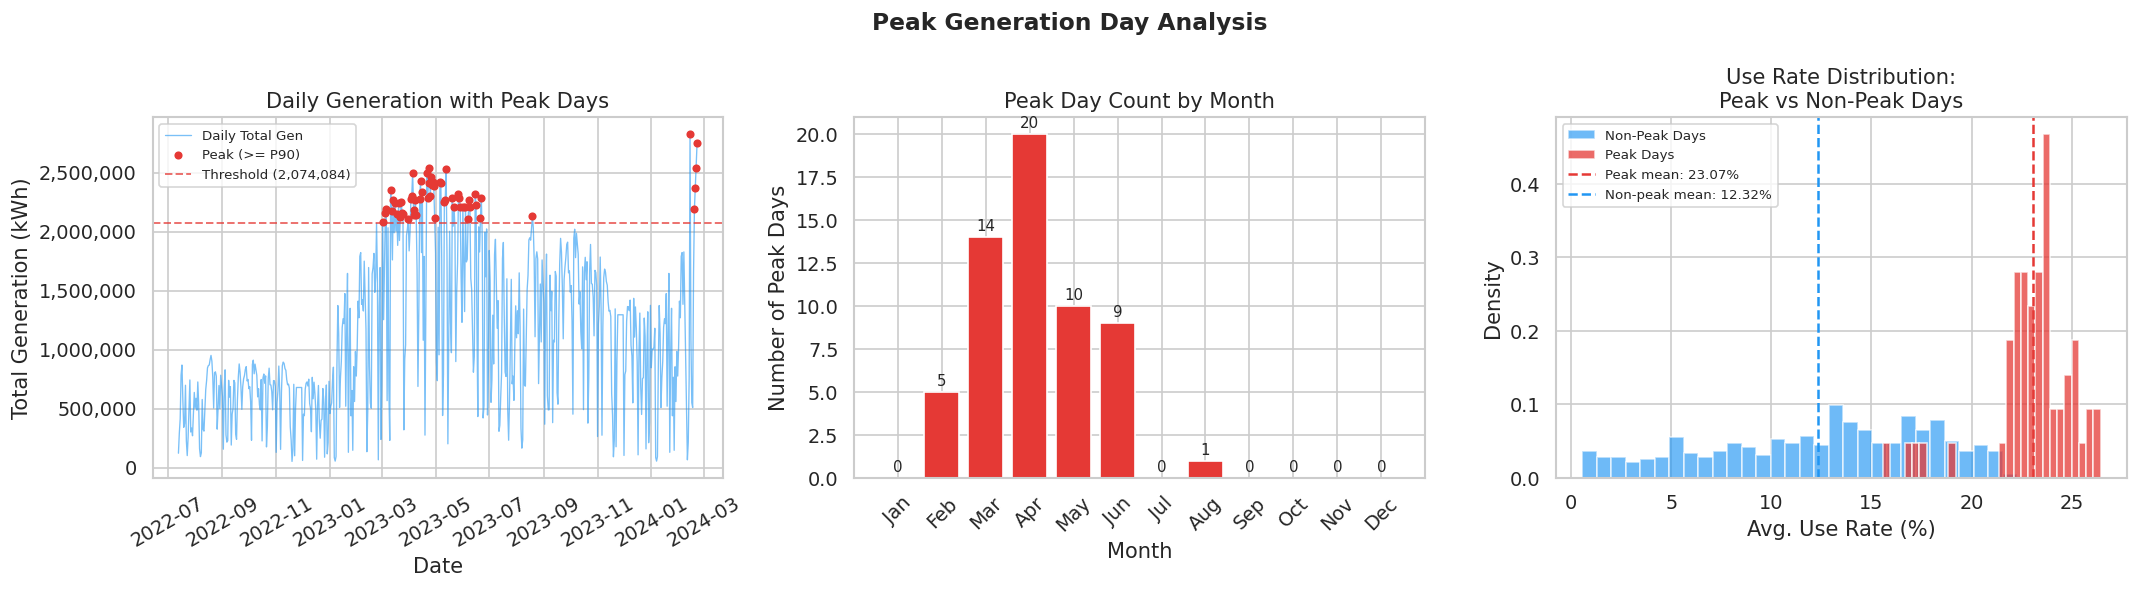


[Analysis 2] Low Generation Risk Day Analysis
  Low threshold (bottom 10%): 280,076.20 kWh
  Low-risk days count : 59

  Bottom 10 Low-Risk Days:
      DATE  YYYY  MM  Daily_Total_Gen  Daily_Avg_Use
2022-11-19  2022  11            51903       0.960000
2023-01-07  2023   1            54533       0.534978
2024-01-07  2024   1            54533       0.534978
2022-12-01  2022  12            59957       1.088497
2023-02-25  2023   2            65283       0.719641
2024-02-11  2024   2            65369       1.244164
2022-12-17  2022  12            70794       1.206601
2023-01-06  2023   1            84819       0.857399
2024-01-06  2024   1            84819       0.857399
2022-12-26  2022  12            87243       1.707778

  Max consecutive low-generation days: 3


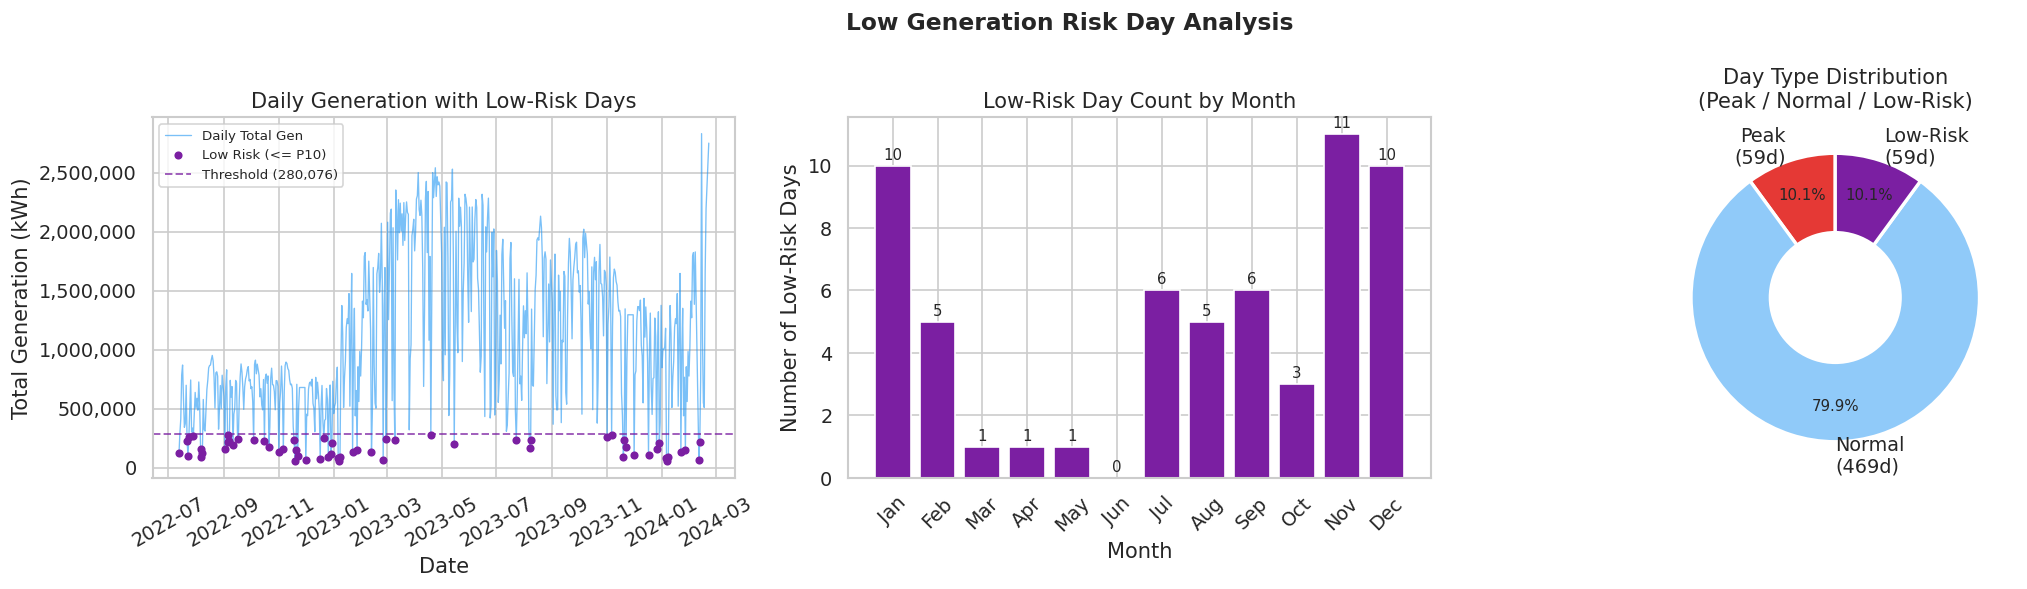


[Analysis 3] High-Volatility Resource Detection
  Volatility threshold (CoV >= 0.5): 292 resources

  Top 10 Volatile Resources (by CoV):
 RE_NUM               VPP_ID  Mean_Gen     Std_Gen  CoV_Gen  Range_Gen
  25903 VPP20240207000000001      15.2   33.988233 2.236068         76
  99912 VPP20240207000000001     447.8  702.745473 1.569329       1629
  29773 VPP20240207000000001    1590.0 2248.342501 1.414052       5404
  99904 VPP20240207000000001    5027.6 7021.060376 1.396503      17204
  99914 VPP20240207000000001    1263.0 1725.631189 1.366295       4065
  99913 VPP20240207000000001    1007.8 1369.604943 1.359005       3237
  31493 VPP20240207000000001    4946.6 6721.569593 1.358826      16352
  29091 VPP20240207000000001    2540.0 3389.204036 1.334332       8164
  28370 VPP20240207000000001    1418.0 1888.777382 1.332001       4604
  33593 VPP20240207000000001    5157.0 6826.838287 1.323800      16424


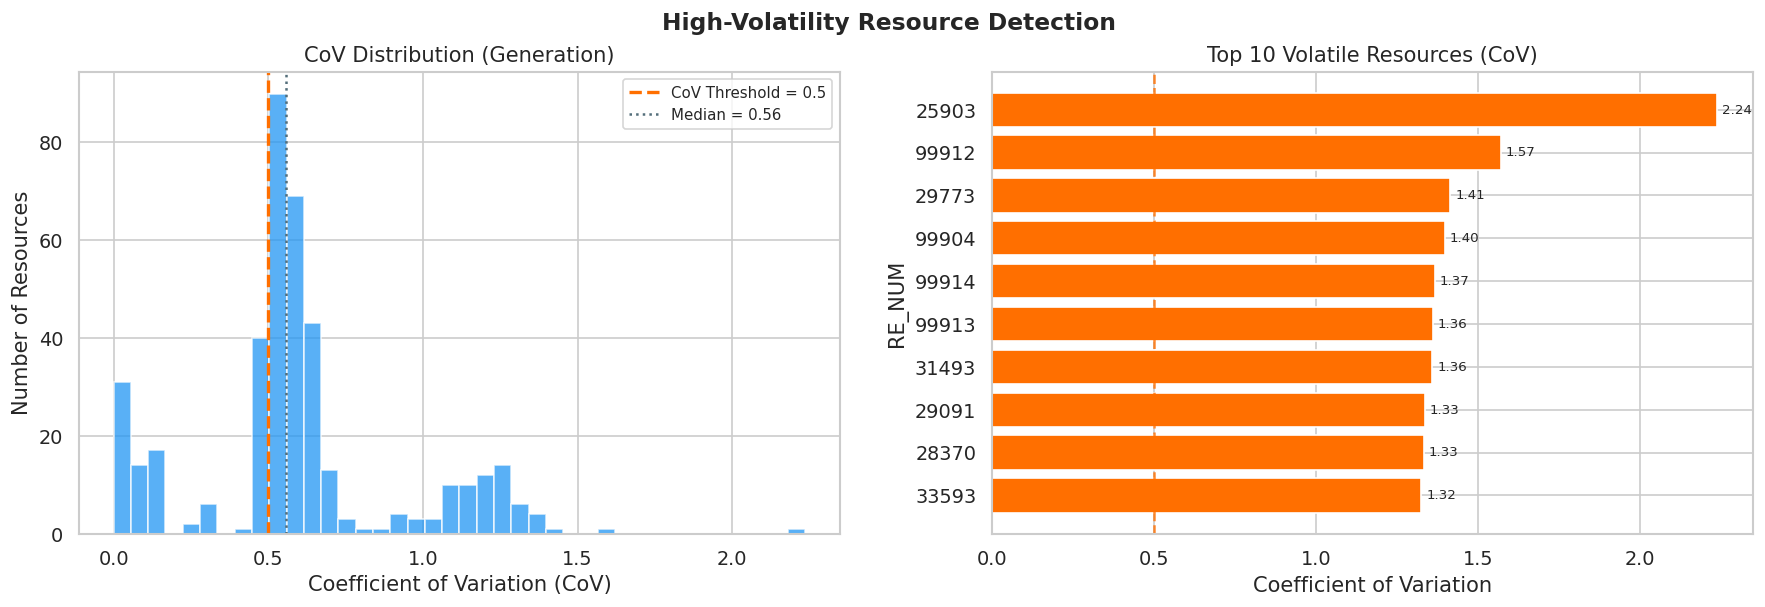

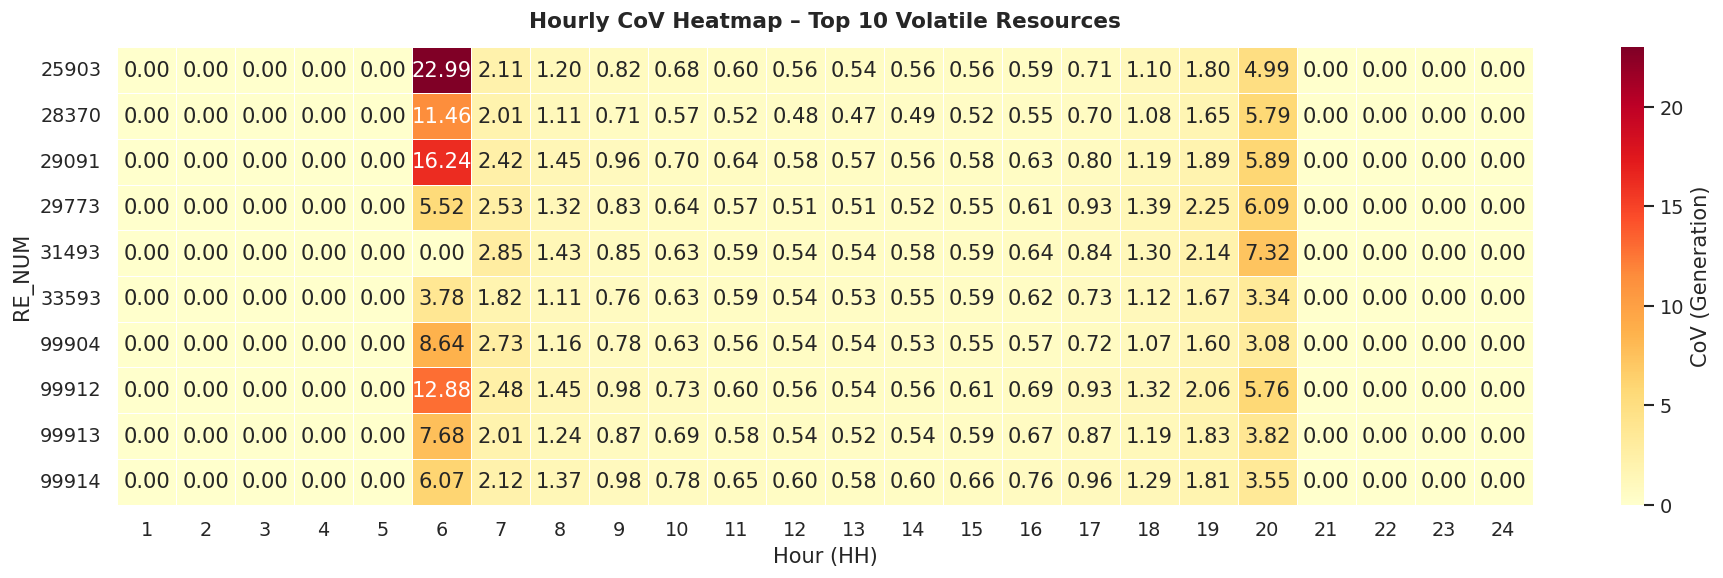


[Analysis 4] Resource Utilization Concentration Analysis
[Top Days by Resource Utilization Concentration]
          DATE       HHI  TOP1_SHARE  RESOURCE_COUNT  TOTAL_GEN_AMOUNT  \
130 2022-11-20  0.058239    0.184093              97            150880   
28  2022-08-10  0.048663    0.189179              97            322208   
157 2022-12-17  0.043220    0.139673              97             70794   
44  2022-08-26  0.037988    0.152041              97            325425   
62  2022-09-13  0.037894    0.159704              97            500064   
179 2023-01-08  0.037209    0.127386              97             93009   
544 2024-01-08  0.037209    0.127386              97             93009   
8   2022-07-21  0.037137    0.160948              97            697417   
12  2022-07-25  0.036881    0.159980              97            492717   
45  2022-08-27  0.035740    0.157768              97            497990   

     TOP3_SHARE  
130    0.355017  
28     0.294419  
157    0.314123  
44    

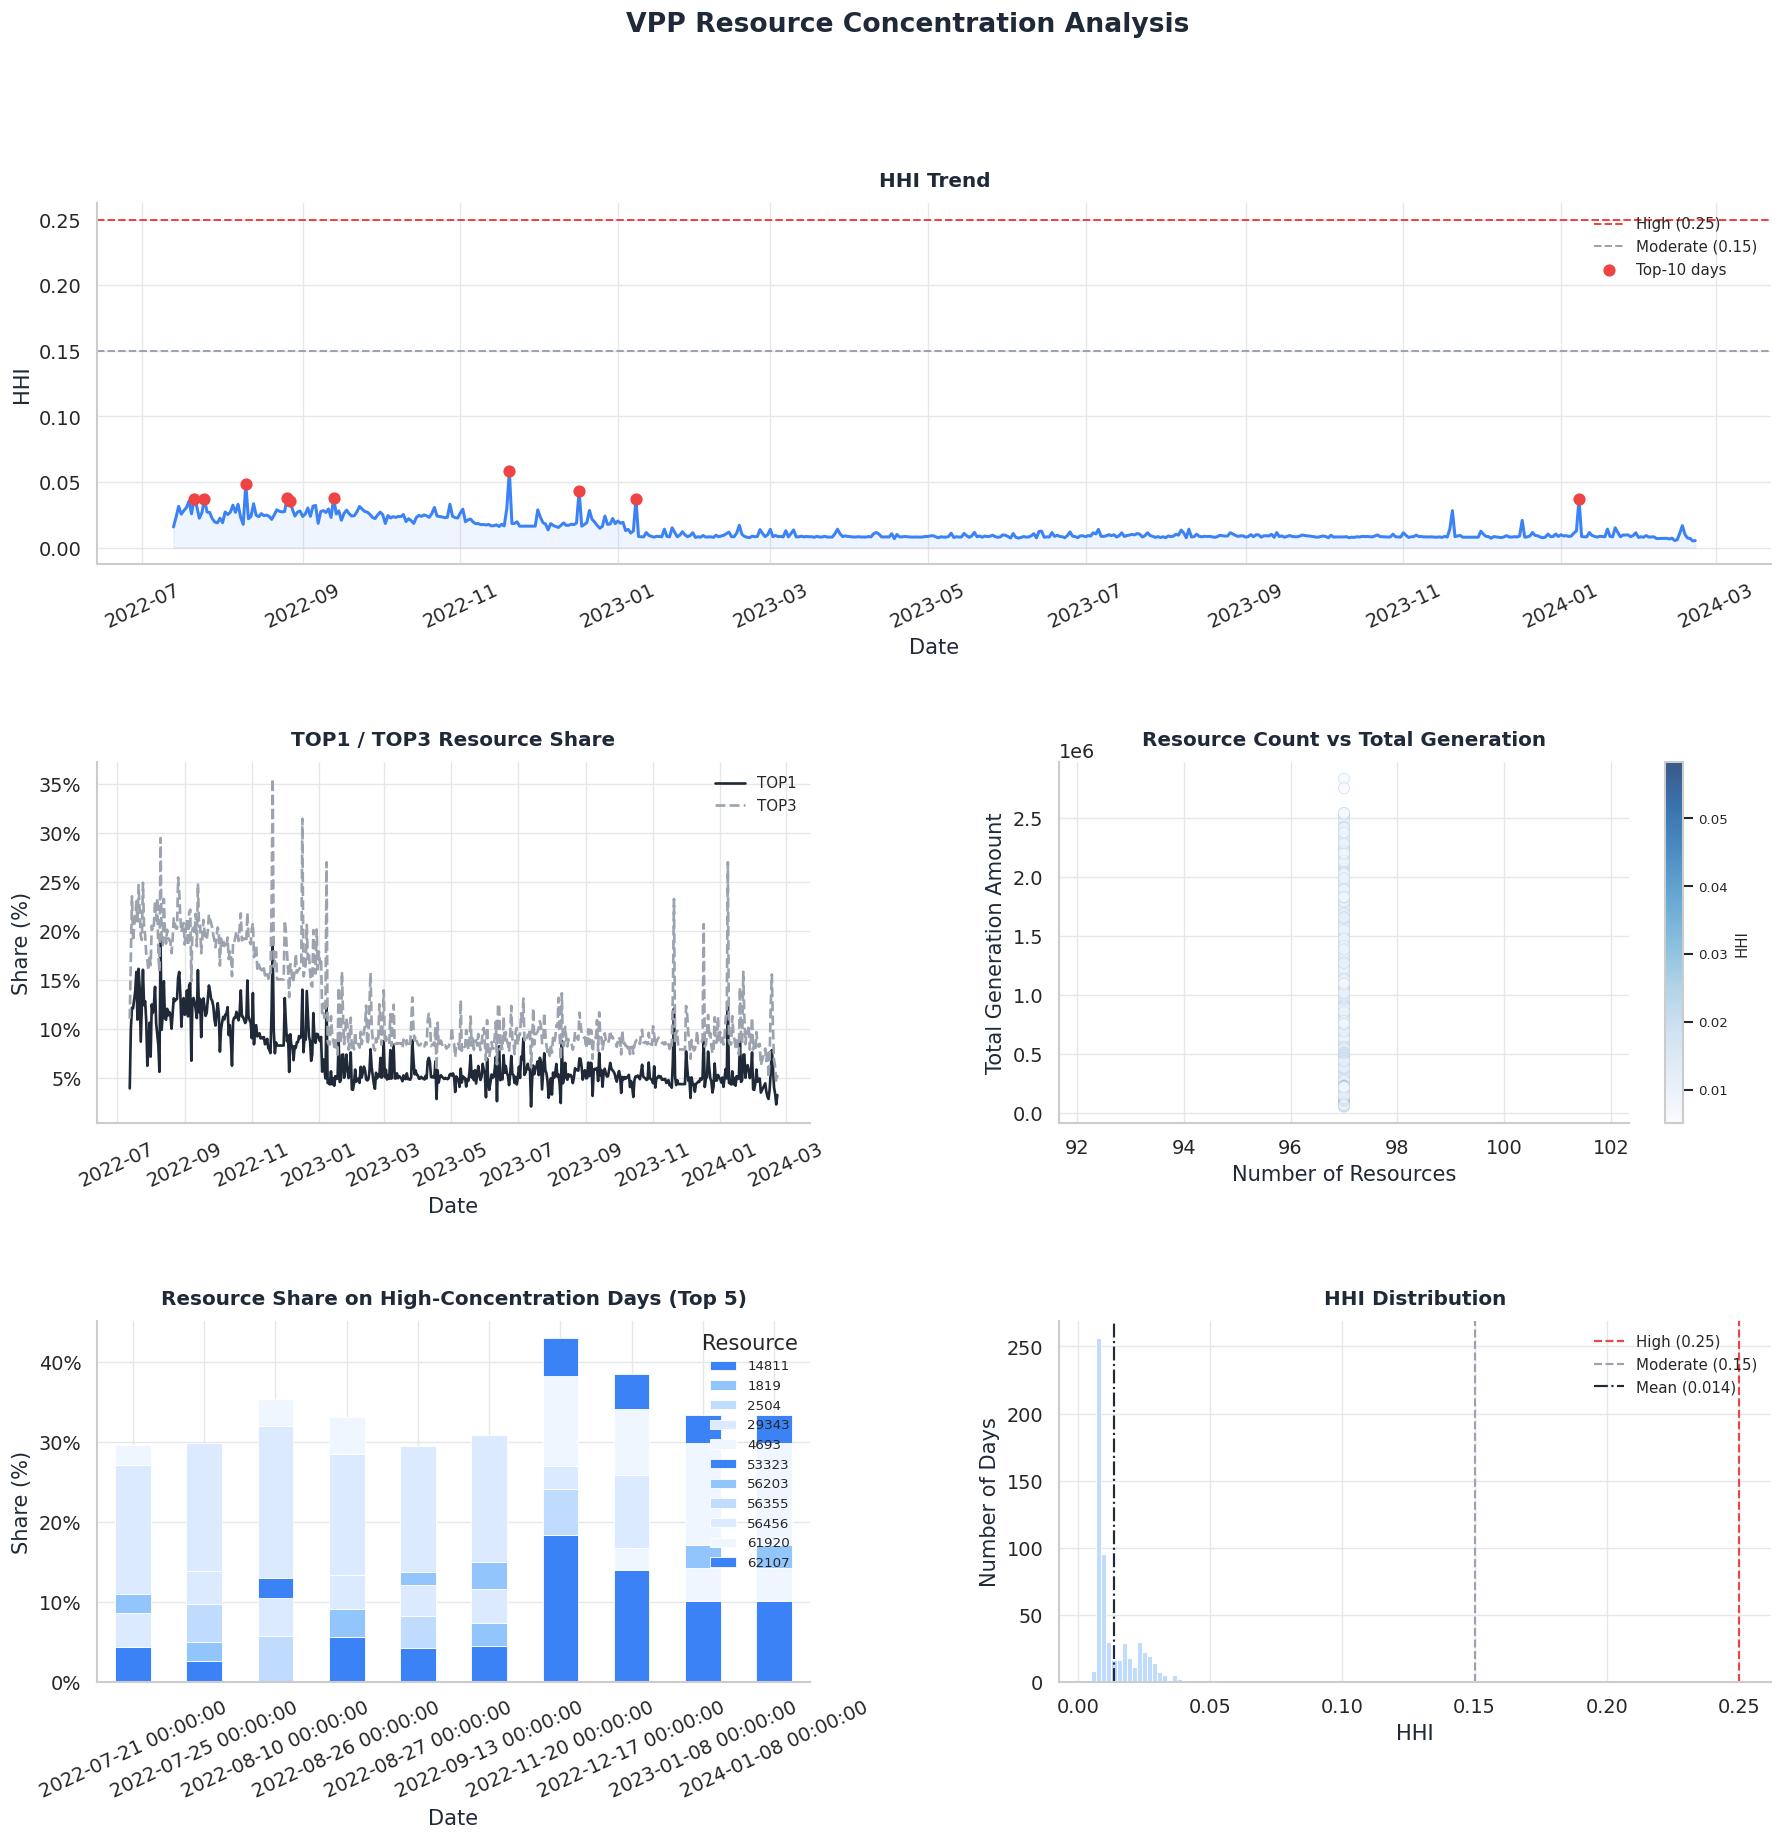

Saved: vpp_concentration_dashboard.png


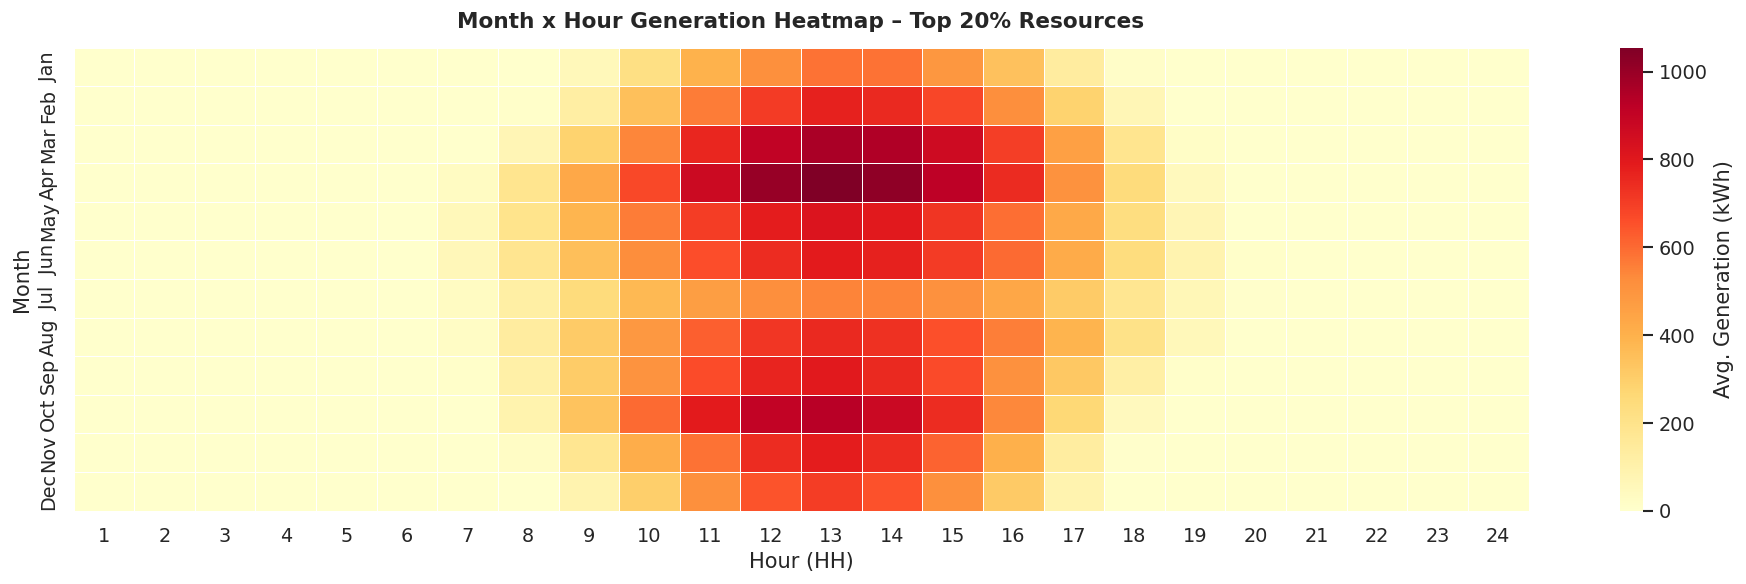

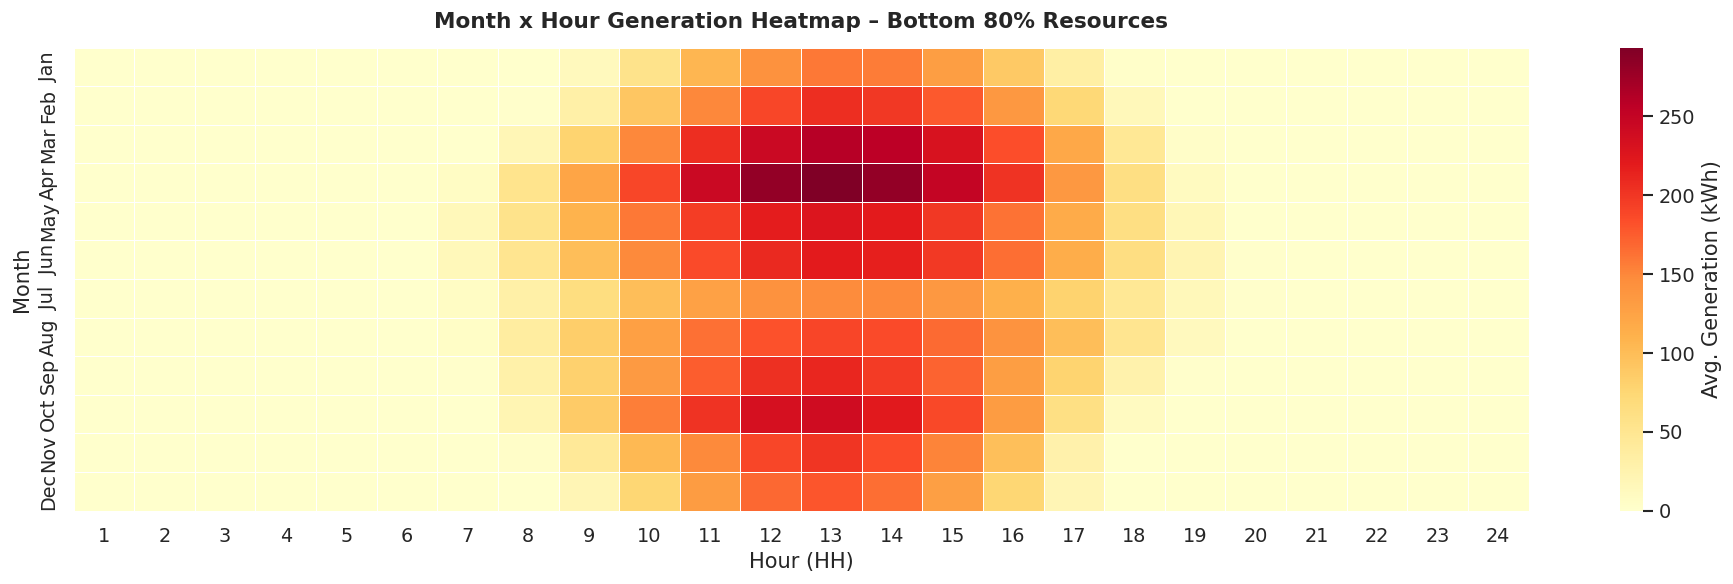

In [ ]:
# ============================================================
# Seoul Energy Simulation - Demand & Resource Utilization Pattern Analysis
# ============================================================
# Prerequisites: daily_clean, hourly_clean, merged_df
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap # Added import for LinearSegmentedColormap
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Font / Style Settings ─────────────────────────────────
plt.rcParams['font.family']       = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi']        = 120
sns.set_style("whitegrid")
sns.set_context("notebook", font_scale=1.05)

# ── Common Palette ────────────────────────────────────────
COLOR_GEN      = "#2196F3"
COLOR_USE      = "#FF7043"
COLOR_PEAK     = "#E53935"
COLOR_LOW      = "#7B1FA2"
COLOR_VOLATILE = "#FF6F00"
COLOR_CONC     = "#00897B"
PALETTE_VPP    = "Set2"

MONTH_LABELS = {
    1:"Jan",2:"Feb",3:"Mar",4:"Apr",5:"May",6:"Jun",
    7:"Jul",8:"Aug",9:"Sep",10:"Oct",11:"Nov",12:"Dec"
}

# ── Thresholds ────────────────────────────────────────────
PEAK_PERCENTILE = 90          # top 10% → peak day
LOW_PERCENTILE  = 10          # bottom 10% → low generation risk
CV_THRESHOLD    = 0.5         # CoV >= 0.5 → high volatility
CONC_TOP_PCT    = 0.2         # top 20% resources carry what % of total generation


# ============================================================
# Analysis 1. Peak Generation Day Analysis
# ============================================================
print("=" * 60)
print("[Analysis 1] Peak Generation Day Analysis")
print("=" * 60)

# Daily total generation across all resources
daily_total = (
    merged_common
    .groupby(["DATE", "YYYY", "MM", "DD"])
    .agg(
        Daily_Total_Gen = ("GEN_AMOUNT_daily",     "sum"), # Corrected column name
        Daily_Avg_Gen    = ("GEN_AMOUNT_daily",     "mean"), # Corrected column name
        Daily_Avg_Use   = ("USE_RATE_daily",       "mean"), # Corrected column name
        Resource_Count   = ("RE_NUM",         "nunique"),
    )
    .reset_index()
    .sort_values("DATE")
)

peak_threshold = np.percentile(daily_total["Daily_Total_Gen"], PEAK_PERCENTILE)
daily_total["Is_Peak"] = daily_total["Daily_Total_Gen"] >= peak_threshold

peak_days = daily_total[daily_total["Is_Peak"]].copy()

print(f"  Peak threshold (top {100 - PEAK_PERCENTILE}%): {peak_threshold:,.2f} kWh")
print(f"  Peak days count : {len(peak_days)}")
print(f"\n  Top 10 Peak Days:")
print(peak_days.sort_values("Daily_Total_Gen", ascending=False)
      .head(10)[["DATE","YYYY","MM","Daily_Total_Gen","Daily_Avg_Use"]]
      .to_string(index=False))

# Peak days distribution by month
peak_by_month = peak_days.groupby("MM").size().reindex(range(1, 13), fill_value=0)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Peak Generation Day Analysis", fontsize=14, fontweight="bold")

# 1-1 Daily total generation timeline with peak highlights
ax = axes[0]
ax.plot(daily_total["DATE"], daily_total["Daily_Total_Gen"],
        color=COLOR_GEN, linewidth=0.8, alpha=0.6, label="Daily Total Gen")
ax.scatter(peak_days["DATE"], peak_days["Daily_Total_Gen"],
           color=COLOR_PEAK, s=15, zorder=5, label=f"Peak (>= P{PEAK_PERCENTILE})")
ax.axhline(peak_threshold, color=COLOR_PEAK, linestyle="--",
           linewidth=1.2, alpha=0.7, label=f"Threshold ({peak_threshold:,.0f})")
ax.set_title("Daily Generation with Peak Days")
ax.set_xlabel("Date")
ax.set_ylabel("Total Generation (kWh)")
ax.legend(fontsize=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.tick_params(axis="x", rotation=30)

# 1-2 Peak day count by month
ax = axes[1]
bars = ax.bar([MONTH_LABELS[m] for m in range(1, 13)],
              peak_by_month.values,
              color=[COLOR_PEAK if v > 0 else "#BDBDBD" for v in peak_by_month.values],
              edgecolor="white")
ax.bar_label(bars, fontsize=9, padding=2)
ax.set_title("Peak Day Count by Month")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Peak Days")
ax.tick_params(axis="x", rotation=45)

# 1-3 Peak vs Non-Peak avg use rate comparison
ax = axes[2]
peak_use    = daily_total[daily_total["Is_Peak"]]["Daily_Avg_Use"]
nonpeak_use = daily_total[~daily_total["Is_Peak"]]["Daily_Avg_Use"]
ax.hist(nonpeak_use, bins=30, color=COLOR_GEN,  alpha=0.65, label="Non-Peak Days", density=True)
ax.hist(peak_use,    bins=30, color=COLOR_PEAK, alpha=0.75, label="Peak Days",     density=True)
ax.axvline(peak_use.mean(),    color=COLOR_PEAK, linestyle="--", linewidth=1.5,
           label=f"Peak mean: {peak_use.mean():.2f}%")
ax.axvline(nonpeak_use.mean(), color=COLOR_GEN,  linestyle="--", linewidth=1.5,
           label=f"Non-peak mean: {nonpeak_use.mean():.2f}%")
ax.set_title("Use Rate Distribution:\nPeak vs Non-Peak Days")
ax.set_xlabel("Avg. Use Rate (%)")
ax.set_ylabel("Density")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("06_peak_day_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print()



# ============================================================
# Analysis 2. Low Generation Risk Day Analysis
# ============================================================
print("=" * 60)
print("[Analysis 2] Low Generation Risk Day Analysis")
print("=" * 60)

low_threshold = np.percentile(daily_total["Daily_Total_Gen"], LOW_PERCENTILE)
daily_total["Is_Low"] = daily_total["Daily_Total_Gen"] <= low_threshold

low_days = daily_total[daily_total["Is_Low"]].copy()

print(f"  Low threshold (bottom {LOW_PERCENTILE}%): {low_threshold:,.2f} kWh")
print(f"  Low-risk days count : {len(low_days)}")
print(f"\n  Bottom 10 Low-Risk Days:")
print(low_days.sort_values("Daily_Total_Gen")
      .head(10)[["DATE","YYYY","MM","Daily_Total_Gen","Daily_Avg_Use"]]
      .to_string(index=False))

low_by_month = low_days.groupby("MM").size().reindex(range(1, 13), fill_value=0)

# Consecutive low-generation streaks
daily_total_sorted = daily_total.sort_values("DATE").copy()
daily_total_sorted["Low_Streak"] = (
    daily_total_sorted["Is_Low"]
    .groupby((daily_total_sorted["Is_Low"] != daily_total_sorted["Is_Low"].shift()).cumsum())
    .transform("sum")
    * daily_total_sorted["Is_Low"]
)
max_streak = daily_total_sorted["Low_Streak"].max()
print(f"\n  Max consecutive low-generation days: {int(max_streak)}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Low Generation Risk Day Analysis", fontsize=14, fontweight="bold")

# 2-1 Daily generation with low-risk highlights
ax = axes[0]
ax.plot(daily_total_sorted["DATE"], daily_total_sorted["Daily_Total_Gen"],
        color=COLOR_GEN, linewidth=0.8, alpha=0.6, label="Daily Total Gen")
ax.scatter(low_days["DATE"], low_days["Daily_Total_Gen"],
           color=COLOR_LOW, s=15, zorder=5, label=f"Low Risk (<= P{LOW_PERCENTILE})")
ax.axhline(low_threshold, color=COLOR_LOW, linestyle="--",
           linewidth=1.2, alpha=0.7, label=f"Threshold ({low_threshold:,.0f})")
ax.set_title("Daily Generation with Low-Risk Days")
ax.set_xlabel("Date")
ax.set_ylabel("Total Generation (kWh)")
ax.legend(fontsize=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.tick_params(axis="x", rotation=30)

# 2-2 Low-risk day count by month
ax = axes[1]
bars = ax.bar([MONTH_LABELS[m] for m in range(1, 13)],
              low_by_month.values,
              color=[COLOR_LOW if v > 0 else "#BDBDBD" for v in low_by_month.values],
              edgecolor="white")
ax.bar_label(bars, fontsize=9, padding=2)
ax.set_title("Low-Risk Day Count by Month")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Low-Risk Days")
ax.tick_params(axis="x", rotation=45)

# 2-3 Peak / Normal / Low-Risk day ratio donut chart
n_peak   = daily_total["Is_Peak"].sum()
n_low    = daily_total["Is_Low"].sum()
n_normal = len(daily_total) - n_peak - n_low
sizes  = [n_peak, n_normal, n_low]
labels = [f"Peak\n({n_peak}d)", f"Normal\n({n_normal}d)", f"Low-Risk\n({n_low}d)"]
colors = [COLOR_PEAK, "#90CAF9", COLOR_LOW]

ax = axes[2]
wedges, texts, autotexts = ax.pie(
    sizes, labels=labels, colors=colors,
    autopct="%1.1f%%", startangle=90,
    wedgeprops={"width": 0.55, "edgecolor": "white", "linewidth": 2},
    pctdistance=0.75
)
for at in autotexts:
    at.set_fontsize(9)
ax.set_title("Day Type Distribution\n(Peak / Normal / Low-Risk)")

plt.tight_layout()
plt.savefig("07_low_risk_day_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print()



#============================================================
# Analysis 3. High-Volatility Resource Detection
# ============================================================
print("=" * 60)
print("[Analysis 3] High-Volatility Resource Detection")
print("=" * 60)

resource_vol = (
    merged_common # Changed merged_df to merged_common
    .groupby(["RE_NUM", "VPP_ID"])
    .agg(
        Mean_Gen  = ("GEN_AMOUNT_daily", "mean"),
        Std_Gen   = ("GEN_AMOUNT_daily", "std"),
        Min_Gen   = ("GEN_AMOUNT_daily", "min"),
        Max_Gen   = ("GEN_AMOUNT_daily", "max"), # Changed GEN_AMOUNT to GEN_AMOUNT_daily
        Mean_Use  = ("USE_RATE_daily",   "mean"),
        Std_Use   = ("USE_RATE_daily",   "std"),
        Count     = ("GEN_AMOUNT_daily", "count"), # Changed GEN_AMOUNT to GEN_AMOUNT_daily
    )
    .reset_index()
)

# Coefficient of Variation (CoV) = Std / Mean
resource_vol["CoV_Gen"] = resource_vol["Std_Gen"] / (resource_vol["Mean_Gen"] + 1e-9)
resource_vol["CoV_Use"] = resource_vol["Std_Use"] / (resource_vol["Mean_Use"] + 1e-9)
resource_vol["Range_Gen"] = resource_vol["Max_Gen"] - resource_vol["Min_Gen"]

resource_vol["Is_Volatile"] = resource_vol["CoV_Gen"] >= CV_THRESHOLD
volatile_resources = resource_vol[resource_vol["Is_Volatile"]].sort_values("CoV_Gen", ascending=False)

print(f"  Volatility threshold (CoV >= {CV_THRESHOLD}): {len(volatile_resources)} resources")
print(f"\n  Top 10 Volatile Resources (by CoV):")
print(volatile_resources.head(10)[
    ["RE_NUM","VPP_ID","Mean_Gen","Std_Gen","CoV_Gen","Range_Gen"]
].to_string(index=False))

top10_volatile = volatile_resources.head(10)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
fig.suptitle("High-Volatility Resource Detection", fontsize=14, fontweight="bold")

# 3-1 CoV distribution with threshold line
ax = axes[0]
ax.hist(resource_vol["CoV_Gen"], bins=40,
        color=COLOR_GEN, alpha=0.75, edgecolor="white")
ax.axvline(CV_THRESHOLD, color=COLOR_VOLATILE, linestyle="--",
           linewidth=2, label=f"CoV Threshold = {CV_THRESHOLD}")
ax.axvline(resource_vol["CoV_Gen"].median(), color="#546E7A", linestyle=":",
           linewidth=1.5, label=f"Median = {resource_vol['CoV_Gen'].median():.2f}")
ax.set_title("CoV Distribution (Generation)")
ax.set_xlabel("Coefficient of Variation (CoV)")
ax.set_ylabel("Number of Resources")
ax.legend(fontsize=9)

# 3-2 Top volatile resources - CoV bar chart
ax = axes[1]
colors_vol = [COLOR_VOLATILE if v else COLOR_GEN
              for v in top10_volatile["Is_Volatile"]]
bars = ax.barh(top10_volatile["RE_NUM"].astype(str),
               top10_volatile["CoV_Gen"],
               color=colors_vol, edgecolor="white")
ax.bar_label(bars, fmt="{:.2f}", fontsize=8, padding=3)
ax.axvline(CV_THRESHOLD, color=COLOR_VOLATILE, linestyle="--",
           linewidth=1.5, alpha=0.8)
ax.set_title(f"Top 10 Volatile Resources (CoV)")
ax.set_xlabel("Coefficient of Variation")
ax.set_ylabel("RE_NUM")
ax.invert_yaxis()

# Hourly CoV heatmap for volatile resources (top 10)
top10_re = volatile_resources["RE_NUM"].head(10).tolist()
hourly_vol = hourly_clean[hourly_clean["RE_NUM"].isin(top10_re)].copy()
hourly_cov_pivot = (
    hourly_vol
    .groupby(["RE_NUM", "HH"])["GEN_AMOUNT"]
    .agg(lambda x: x.std() / (x.mean() + 1e-9))
    .reset_index()
    .pivot(index="RE_NUM", columns="HH", values="GEN_AMOUNT")
)

if not hourly_cov_pivot.empty:
    fig, ax = plt.subplots(figsize=(16, 5))
    sns.heatmap(hourly_cov_pivot, annot=True, fmt=".2f", cmap="YlOrRd",
                linewidths=0.4, linecolor="white", ax=ax,
                cbar_kws={"label": "CoV (Generation)"})
    ax.set_title("Hourly CoV Heatmap – Top 10 Volatile Resources",
                 fontsize=13, fontweight="bold", pad=12)
    ax.set_xlabel("Hour (HH)")
    ax.set_ylabel("RE_NUM")
    plt.tight_layout()
    plt.savefig("08_volatile_hourly_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show()
print()



# ============================================================
# Analysis 4. Resource Utilization Concentration Analysis
# ============================================================
print("=" * 60)
print("[Analysis 4] Resource Utilization Concentration Analysis")
print("=" * 60)

resource_share_by_day = (
    merged_common
    .groupby(["DATE", "VPP_ID", "RE_NUM"], as_index=False)
    .agg(
        RESOURCE_GEN_AMOUNT=("GEN_AMOUNT_daily", "sum"),
        RESOURCE_USE_RATE=("USE_RATE_daily", "mean")
    )
)

daily_gen_sum = (
    resource_share_by_day
    .groupby("DATE", as_index=False)
    .agg(
        TOTAL_GEN_AMOUNT=("RESOURCE_GEN_AMOUNT", "sum")
    )
)

resource_share_by_day = pd.merge(
    resource_share_by_day,
    daily_gen_sum,
    on="DATE",
    how="left"
)

resource_share_by_day["GEN_SHARE"] = (
    resource_share_by_day["RESOURCE_GEN_AMOUNT"] /
    resource_share_by_day["TOTAL_GEN_AMOUNT"].replace(0, np.nan)
)

# 날짜별 HHI 계산
daily_concentration = (
    resource_share_by_day
    .groupby("DATE", as_index=False)
    .agg(
        HHI=("GEN_SHARE", lambda x: np.sum(x ** 2)),
        TOP1_SHARE=("GEN_SHARE", "max"),
        RESOURCE_COUNT=("RE_NUM", "nunique"),
        TOTAL_GEN_AMOUNT=("TOTAL_GEN_AMOUNT", "first")
    )
)

# TOP3 자원 비중 계산
top3_share = (
    resource_share_by_day
    .sort_values(["DATE", "GEN_SHARE"], ascending=[True, False])
    .groupby("DATE")
    .head(3)
    .groupby("DATE", as_index=False)
    .agg(
        TOP3_SHARE=("GEN_SHARE", "sum")
    )
)

daily_concentration = pd.merge(
    daily_concentration,
    top3_share,
    on="DATE",
    how="left"
)

daily_concentration = daily_concentration.sort_values("HHI", ascending=False)

print("[Top Days by Resource Utilization Concentration]")
print(daily_concentration.head(10))


# 집중도가 높은 날의 주요 자원 확인
high_concentration_dates = daily_concentration.head(10)["DATE"]

high_concentration_resource = resource_share_by_day[
    resource_share_by_day["DATE"].isin(high_concentration_dates)
].sort_values(["DATE", "GEN_SHARE"], ascending=[True, False])

print("[Resource Contribution Shares on High-Concentration Days]")
print(high_concentration_resource.head(10))


plt.rcParams.update({
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.grid":          True,
    "grid.color":         "#E5E7EB",
    "grid.linewidth":     0.8,
    "axes.unicode_minus": False,
    "font.size":          11,
})

BLUE  = "#3B82F6"
RED   = "#EF4444"
GRAY  = "#9CA3AF"
DARK  = "#1F2937"
BG    = "#FFFFFF"

fig = plt.figure(figsize=(18, 16))
fig.patch.set_facecolor(BG)
fig.suptitle("VPP Resource Concentration Analysis", fontsize=16, fontweight="bold",
             color=DARK, y=0.98)

gs = GridSpec(3, 2, figure=fig, hspace=0.55, wspace=0.35)
ax1 = fig.add_subplot(gs[0, :])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[1, 1])
ax4 = fig.add_subplot(gs[2, 0])
ax5 = fig.add_subplot(gs[2, 1])

for ax in [ax1, ax2, ax3, ax4, ax5]:
    ax.set_facecolor(BG)


# ── Panel 1 ▸ HHI Trend ────────────────────────────────────
dc_sorted = daily_concentration.sort_values("DATE")
dates = dc_sorted["DATE"]

ax1.plot(dates, dc_sorted["HHI"], color=BLUE, lw=1.8)
ax1.fill_between(dates, dc_sorted["HHI"], alpha=0.08, color=BLUE)
ax1.axhline(0.25, color=RED,  lw=1.2, ls="--", label="High (0.25)")
ax1.axhline(0.15, color=GRAY, lw=1.2, ls="--", label="Moderate (0.15)")

top10_dates = daily_concentration.head(10)["DATE"]
top10_dc = dc_sorted[dc_sorted["DATE"].isin(top10_dates)]
ax1.scatter(top10_dc["DATE"], top10_dc["HHI"],
            color=RED, s=40, zorder=5, label="Top-10 days")

ax1.set_title("HHI Trend", fontsize=12, fontweight="bold", color=DARK, pad=10)
ax1.set_xlabel("Date", color=DARK)
ax1.set_ylabel("HHI", color=DARK)
ax1.legend(fontsize=9, framealpha=0)
ax1.tick_params(axis="x", rotation=25)


# ── Panel 2 ▸ TOP1 / TOP3 Share ────────────────────────────
ax2.plot(dates, dc_sorted["TOP1_SHARE"] * 100, color=DARK,  lw=1.6, label="TOP1")
ax2.plot(dates, dc_sorted["TOP3_SHARE"] * 100, color=GRAY,  lw=1.6, label="TOP3", ls="--")

ax2.set_title("TOP1 / TOP3 Resource Share", fontsize=12, fontweight="bold", color=DARK, pad=10)
ax2.set_xlabel("Date", color=DARK)
ax2.set_ylabel("Share (%)", color=DARK)
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
ax2.legend(fontsize=9, framealpha=0)
ax2.tick_params(axis="x", rotation=25)


# ── Panel 3 ▸ Resource Count vs Total Generation ───────────
sc = ax3.scatter(
    dc_sorted["RESOURCE_COUNT"],
    dc_sorted["TOTAL_GEN_AMOUNT"],
    c=dc_sorted["HHI"], cmap="Blues",
    s=45, alpha=0.8, edgecolors="#CBD5E1", lw=0.4
)
cb = plt.colorbar(sc, ax=ax3)
cb.set_label("HHI", fontsize=9)
cb.ax.tick_params(labelsize=8)

ax3.set_title("Resource Count vs Total Generation", fontsize=12, fontweight="bold", color=DARK, pad=10)
ax3.set_xlabel("Number of Resources", color=DARK)
ax3.set_ylabel("Total Generation Amount", color=DARK)


# ── Panel 4 ▸ Stacked Bar – High Concentration Days ────────
TOP_N = 5
STACK_COLORS = ["#3B82F6", "#93C5FD", "#BFDBFE", "#DBEAFE", "#EFF6FF"]

pivot = (
    high_concentration_resource
    .groupby("DATE")
    .head(TOP_N)
    .assign(RE_LABEL=lambda d: d["RE_NUM"].astype(str))
    .pivot_table(index="DATE", columns="RE_LABEL",
                 values="GEN_SHARE", aggfunc="sum", fill_value=0)
)

pivot.plot(kind="bar", stacked=True, ax=ax4,
           color=STACK_COLORS[:len(pivot.columns)],
           edgecolor="white", linewidth=0.5)

ax4.set_title(f"Resource Share on High-Concentration Days (Top {TOP_N})",
              fontsize=12, fontweight="bold", color=DARK, pad=10)
ax4.set_xlabel("Date", color=DARK)
ax4.set_ylabel("Share (%)", color=DARK)
ax4.tick_params(axis="x", rotation=25)
ax4.legend(title="Resource", fontsize=8, framealpha=0, loc="upper right")
ax4.set_yticklabels([f"{int(t*100)}%" for t in ax4.get_yticks()])


# ── Panel 5 ▸ HHI Distribution ─────────────────────────────
ax5.hist(daily_concentration["HHI"], bins=28,
         color="#BFDBFE", edgecolor="white", linewidth=0.6)
ax5.axvline(0.25, color=RED,  lw=1.3, ls="--", label="High (0.25)")
ax5.axvline(0.15, color=GRAY, lw=1.3, ls="--", label="Moderate (0.15)")
ax5.axvline(daily_concentration["HHI"].mean(), color=DARK, lw=1.3, ls="-.",
            label=f"Mean ({daily_concentration['HHI'].mean():.3f})")

ax5.set_title("HHI Distribution", fontsize=12, fontweight="bold", color=DARK, pad=10)
ax5.set_xlabel("HHI", color=DARK)
ax5.set_ylabel("Number of Days", color=DARK)
ax5.legend(fontsize=9, framealpha=0)


plt.savefig("vpp_concentration_dashboard.png", dpi=150,
            bbox_inches="tight", facecolor=BG)
plt.show()
print("Saved: vpp_concentration_dashboard.png")

# 4-4 Concentration tier heatmap (Month x Hour for top-tier vs low-tier resources)
resource_conc = resource_summary.copy()
top_n_res = int(len(resource_conc) * CONC_TOP_PCT)

tier_cut = resource_conc.iloc[:top_n_res]["RE_NUM"].tolist()
hourly_clean["Tier"] = np.where(hourly_clean["RE_NUM"].isin(tier_cut), "Top Tier", "Low Tier")

pivot_top = hourly_clean[hourly_clean["Tier"] == "Top Tier"].pivot_table(
    index="MM", columns="HH", values="GEN_AMOUNT", aggfunc="mean"
)
pivot_low = hourly_clean[hourly_clean["Tier"] == "Low Tier"].pivot_table(
    index="MM", columns="HH", values="GEN_AMOUNT", aggfunc="mean"
)

for pivot, tier_label, fname in [
    (pivot_top, f"Top {int(CONC_TOP_PCT*100)}% Resources", "09a_top_tier_heatmap.png"),
    (pivot_low, f"Bottom {int((1-CONC_TOP_PCT)*100)}% Resources", "09b_low_tier_heatmap.png"),
]:
    if pivot.empty:
        continue
    pivot.index = [MONTH_LABELS.get(m, m) for m in pivot.index]
    fig, ax = plt.subplots(figsize=(16, 5))
    sns.heatmap(pivot, annot=False, cmap="YlOrRd",
                linewidths=0.3, linecolor="white", ax=ax,
                cbar_kws={"label": "Avg. Generation (kWh)"})
    ax.set_title(f"Month x Hour Generation Heatmap – {tier_label}",
                 fontsize=13, fontweight="bold", pad=12)
    ax.set_xlabel("Hour (HH)")
    ax.set_ylabel("Month")
    plt.tight_layout()
    plt.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()


데이터 shape: (309166, 10)  /  기간: 2022-07-13 ~ 2025-11-24
Train 247007행  /  Test 61752행

── 성능 요약 ──────────────────────────
                   MAE      RMSE     R2          MAPE
Ridge         1303.390  2472.087  0.894  2.950686e+10
RandomForest   983.084  1467.404  0.962  1.679157e+09
XGBoost        418.277   647.602  0.993  2.824560e+10


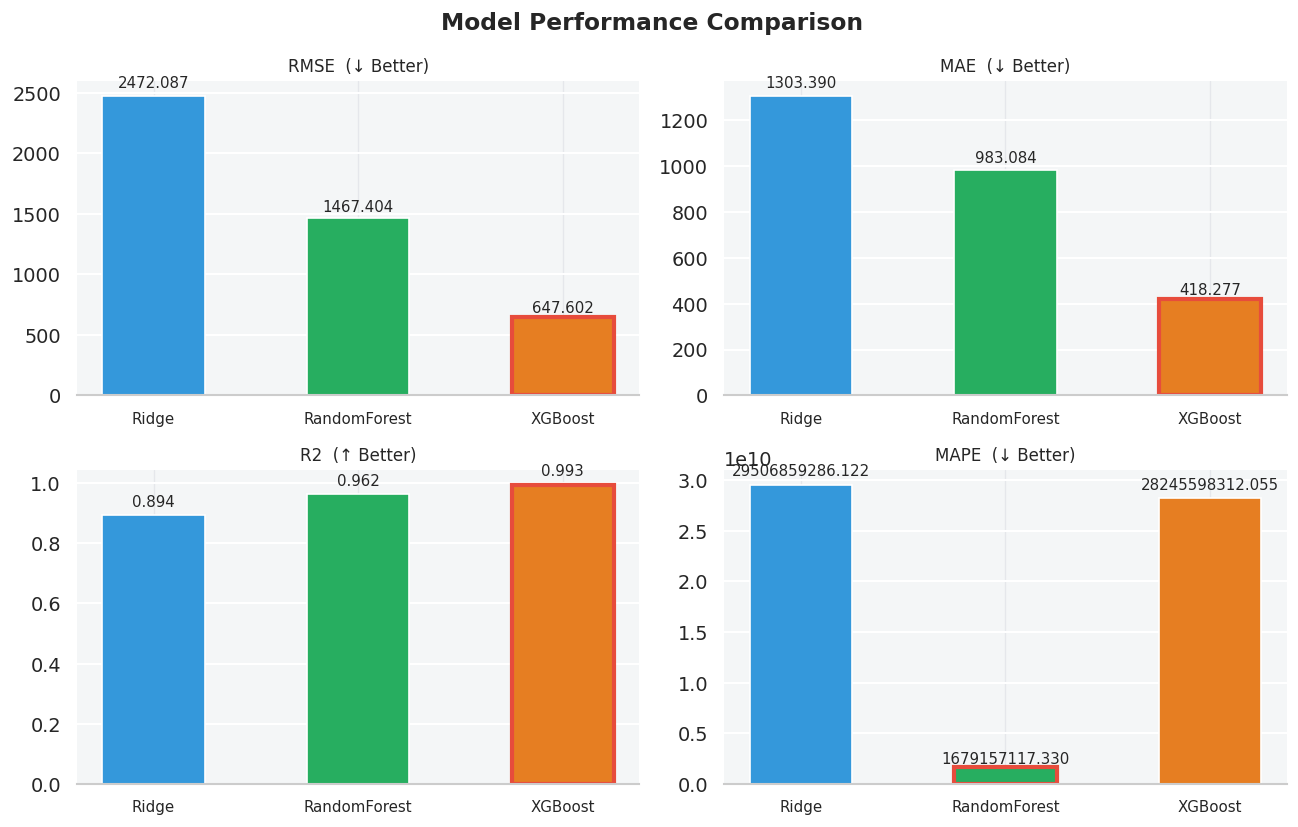

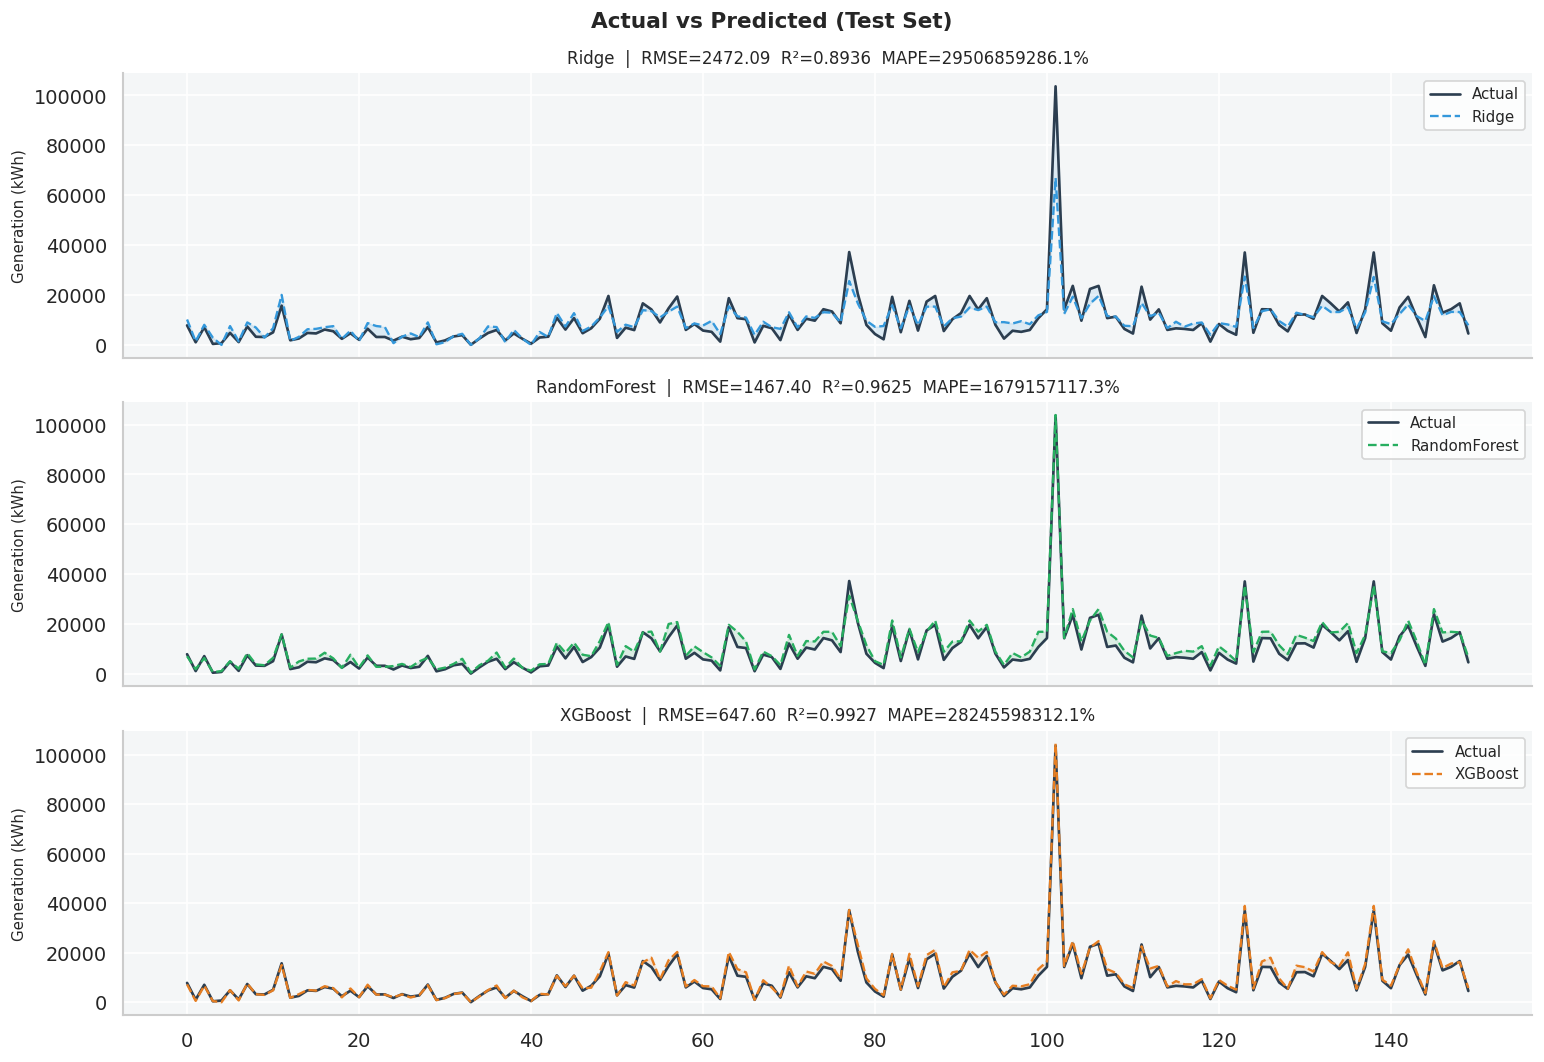

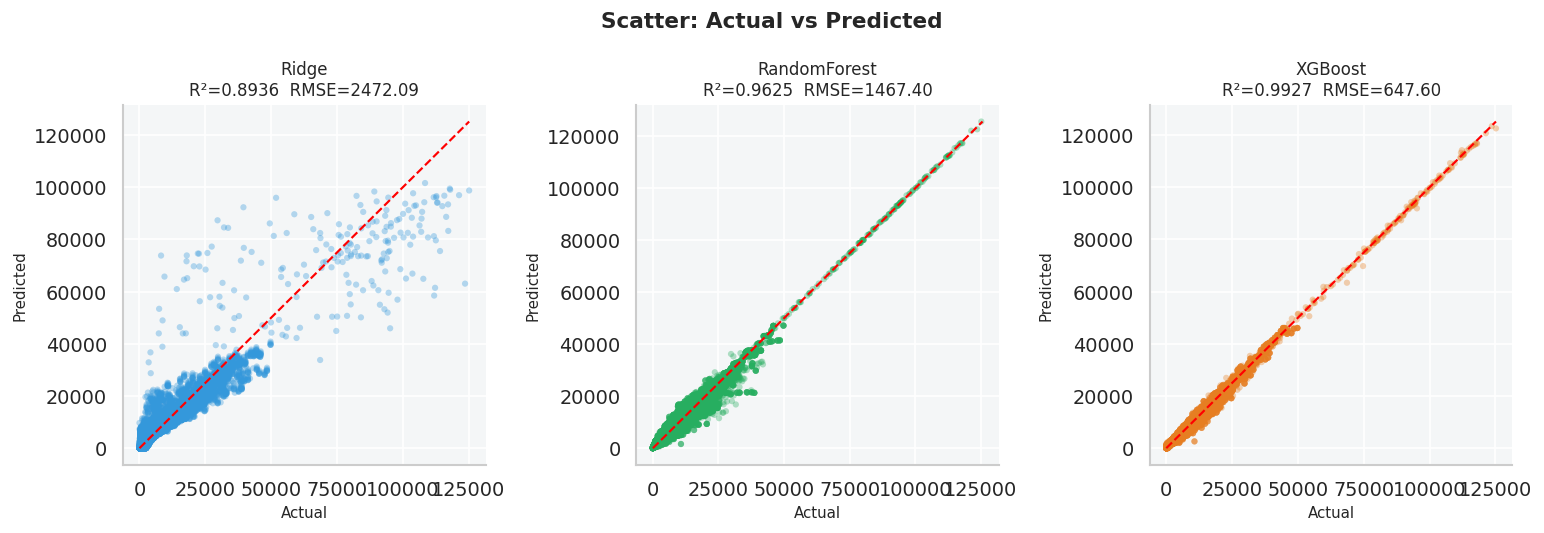

In [ ]:
import warnings; warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except ImportError:
    from sklearn.ensemble import GradientBoostingRegressor
    HAS_XGB = False
    print("[INFO] XGBoost 없음 → GradientBoosting 으로 대체")

matplotlib.rcParams.update({"font.family": "DejaVu Sans", "axes.unicode_minus": False})

# ── 경로 설정 ────────────────────────────────────────────────
PATH_DAILY  = "/content/서울에너지 시뮬레이션 일일단위자원별계측실적.csv"
PATH_HOURLY = "/content/서울에너지 시뮬레이션 시간단위자원별계측실적.csv"

# ══════════════════════════════════════════════════════════════
# 1. 전처리 (기존 로직 그대로)
# ══════════════════════════════════════════════════════════════
daily_df  = pd.read_csv(PATH_DAILY)
hourly_df = pd.read_csv(PATH_HOURLY, engine="python")

def add_date(df):
    df = df.copy()
    df["DATE"] = pd.to_datetime(df[["YYYY","MM","DD"]].rename(
        columns={"YYYY":"year","MM":"month","DD":"day"}))
    return df

daily_df  = add_date(daily_df)
hourly_df = add_date(hourly_df)

hourly_agg = (
    hourly_df.drop(columns=["SOC_RATE","USKI_AMOUNT"], errors="ignore")
    .groupby(["DATE","VPP_ID","RE_NUM"], as_index=False)
    .agg(GEN_hourly_sum=("GEN_AMOUNT","sum"),
         USE_hourly_mean=("USE_RATE","mean"))
)

daily_clean = (daily_df
    .drop(columns=["SOC_RATE","USKI_AMOUNT"], errors="ignore")
    .rename(columns={"GEN_AMOUNT":"GEN_daily","USE_RATE":"USE_daily"}))

df = pd.merge(daily_clean, hourly_agg,
              on=["DATE","VPP_ID","RE_NUM"], how="inner")
df = df.sort_values("DATE").reset_index(drop=True)

print(f"데이터 shape: {df.shape}  /  기간: {df['DATE'].min().date()} ~ {df['DATE'].max().date()}")

# ══════════════════════════════════════════════════════════════
# 2. 피처 엔지니어링 (간결하게)
# ══════════════════════════════════════════════════════════════
TARGET = "GEN_daily"

df["month"]      = df["DATE"].dt.month
df["dayofweek"]  = df["DATE"].dt.dayofweek
df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)
df["season"]     = df["month"].map(
    {12:4,1:4,2:4, 3:1,4:1,5:1, 6:2,7:2,8:2, 9:3,10:3,11:3})

df = df.sort_values(["VPP_ID","RE_NUM","DATE"])
df["GEN_lag1"]    = df.groupby(["VPP_ID","RE_NUM"])[TARGET].shift(1)
df["GEN_roll7"]   = (df.groupby(["VPP_ID","RE_NUM"])[TARGET]
                       .transform(lambda x: x.shift(1).rolling(7, min_periods=1).mean()))
df["USE_lag1"]    = df.groupby(["VPP_ID","RE_NUM"])["USE_daily"].shift(1)

df = pd.get_dummies(df, columns=["VPP_ID","RE_NUM"], drop_first=False, dtype=int)
df = df.sort_values("DATE").reset_index(drop=True)

FEATURES = [c for c in df.columns
            if c not in ["DATE","YYYY","MM","DD",TARGET,"GEN_hourly_sum"]]

df = df.dropna(subset=[TARGET,"GEN_lag1","GEN_roll7"]).reset_index(drop=True)
X, y = df[FEATURES].fillna(0), df[TARGET]

# ══════════════════════════════════════════════════════════════
# 3. Train / Test 분할 (시계열 80 / 20)
# ══════════════════════════════════════════════════════════════
split = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

print(f"Train {X_train.shape[0]}행  /  Test {X_test.shape[0]}행")

# ══════════════════════════════════════════════════════════════
# 4. 모델 학습 & 평가
# ══════════════════════════════════════════════════════════════
models = {
    "Ridge": Pipeline([("sc", StandardScaler()), ("m", Ridge(alpha=10))]),
    "RandomForest": RandomForestRegressor(n_estimators=200, max_depth=8,
                                          random_state=42, n_jobs=-1),
    "XGBoost" if HAS_XGB else "GradBoost": (
        XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=5,
                     subsample=0.8, random_state=42, verbosity=0)
        if HAS_XGB else
        GradientBoostingRegressor(n_estimators=200, learning_rate=0.05,
                                  max_depth=5, random_state=42)
    ),
}

preds, metrics = {}, {}
for name, model in models.items():
    model.fit(X_train, y_train)
    p = np.clip(model.predict(X_test), 0, None)
    preds[name] = p
    metrics[name] = {
        "MAE":    mean_absolute_error(y_test, p),
        "RMSE":   np.sqrt(mean_squared_error(y_test, p)),
        "R2":     r2_score(y_test, p),
        "MAPE":   np.mean(np.abs((y_test - p) / (y_test + 1e-9))) * 100,
    }

mdf = pd.DataFrame(metrics).T
print("\n── 성능 요약 ──────────────────────────")
print(mdf.round(3).to_string())

# ══════════════════════════════════════════════════════════════
# 5. 시각화
# ══════════════════════════════════════════════════════════════
PALETTE = {
    "Ridge":        "#3498DB",
    "RandomForest": "#27AE60",
    "XGBoost":      "#E67E22",
    "GradBoost":    "#E67E22",
    "actual":       "#2C3E50",
    "bg":           "#F4F6F7",
}

model_names = list(models.keys())

# ── Fig 1 : 성능 비교 (2×2 bar) ─────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
fig.suptitle("Model Performance Comparison", fontsize=14, fontweight="bold")
fig.patch.set_facecolor("white")

for ax, metric in zip(axes.flat, ["RMSE","MAE","R2","MAPE"]):
    vals   = [metrics[m][metric] for m in model_names]
    colors = [PALETTE.get(m, "#95A5A6") for m in model_names]
    best   = np.argmax(vals) if metric == "R2" else np.argmin(vals)

    bars = ax.bar(model_names, vals, color=colors, width=0.5, edgecolor="white")
    bars[best].set_edgecolor("#E74C3C"); bars[best].set_linewidth(2.5)

    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
                f"{v:.3f}", ha="center", va="bottom", fontsize=9)

    label = "↑ Better" if metric == "R2" else "↓ Better"
    ax.set_title(f"{metric}  ({label})", fontsize=10)
    ax.set_facecolor(PALETTE["bg"])
    ax.grid(axis="y", color="white", linewidth=1.2)
    ax.spines[["top","right","left"]].set_visible(False)
    ax.tick_params(axis="x", labelsize=9)

plt.tight_layout()
plt.savefig("fig1_performance.png", dpi=130, bbox_inches="tight")
plt.show()

# ── Fig 2 : 실제 vs 예측 (시계열, 3개 subplot) ──────────────
MAX_PT = 150   # 보기 좋게 앞 150개만
sl = slice(0, min(len(y_test), MAX_PT))

fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
fig.suptitle("Actual vs Predicted (Test Set)", fontsize=13, fontweight="bold")
fig.patch.set_facecolor("white")

for ax, name in zip(axes, model_names):
    m = metrics[name]
    ax.plot(y_test.values[sl],    lw=1.6, color=PALETTE["actual"], label="Actual", zorder=3)
    ax.plot(preds[name][sl],      lw=1.4, color=PALETTE.get(name,"#95A5A6"),
            linestyle="--", label=name, zorder=4)
    ax.fill_between(range(sl.stop - sl.start),
                    y_test.values[sl], preds[name][sl],
                    alpha=0.12, color=PALETTE.get(name,"#95A5A6"))
    ax.set_title(f"{name}  |  RMSE={m['RMSE']:.2f}  R²={m['R2']:.4f}  MAPE={m['MAPE']:.1f}%",
                 fontsize=10)
    ax.set_ylabel("Generation (kWh)", fontsize=9)
    ax.set_facecolor(PALETTE["bg"])
    ax.grid(color="white", linewidth=1.0)
    ax.spines[["top","right"]].set_visible(False)
    ax.legend(fontsize=9, loc="upper right")

plt.tight_layout()
plt.savefig("fig2_actual_vs_predicted.png", dpi=130, bbox_inches="tight")
plt.show()

# ── Fig 3 : Scatter — 3개 나란히 ────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
fig.suptitle("Scatter: Actual vs Predicted", fontsize=13, fontweight="bold")
fig.patch.set_facecolor("white")

for ax, name in zip(axes, model_names):
    m    = metrics[name]
    pred = preds[name]
    lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]

    ax.scatter(y_test, pred, alpha=0.35, s=14,
               color=PALETTE.get(name,"#95A5A6"), edgecolors="none")
    ax.plot(lims, lims, "r--", lw=1.3)
    ax.set_title(f"{name}\nR²={m['R2']:.4f}  RMSE={m['RMSE']:.2f}", fontsize=10)
    ax.set_xlabel("Actual", fontsize=9)
    ax.set_ylabel("Predicted", fontsize=9)
    ax.set_facecolor(PALETTE["bg"])
    ax.grid(color="white", linewidth=1.0)
    ax.spines[["top","right"]].set_visible(False)

plt.tight_layout()
plt.savefig("fig3_scatter.png", dpi=130, bbox_inches="tight")
plt.show()